## Setup

Install dependencies with:

```bash
pip install -r requirements.txt
```


# Study 2 Analysis

Implements the preregistered analysis for Study 2 (AsPredicted #286,030, registered 2026-04-19) plus exploratory analyses.

**Design.** 2 × 2: Schema vs. Non-Schema × type of round-4 environmental change (Ambiguously Incompatible vs. Obviously Incompatible).

| Paper condition | Code variable | Treatment string |
|---|---|---|
| Schema × Ambiguously Incompatible | `schema` / `ambiguous` | `schema` |
| Non-Schema × Ambiguously Incompatible | `nonschema` / `ambiguous` | `nonschema` |
| Schema × Obviously Incompatible | `schema` / `incompatible` | `schema_tangrams` |
| Non-Schema × Obviously Incompatible | `nonschema` / `incompatible` | `nonschema_tangrams` |

In this notebook the internal variable values `ambiguous` and `incompatible` correspond to the paper's **Ambiguously Incompatible** and **Obviously Incompatible** conditions, respectively.

**Preregistered hypothesis (H1).** Within the Schema condition, groups are more likely to *use a schema* in R4 under Ambiguously Incompatible than under Obviously Incompatible change. Tested with a one-tailed Fisher's exact test on the binarized schema-use DV (a group is coded as using a schema in a round if all members used schema-based names for > half of the 8 images). Schema-use coding is done by three independent human coders, majority vote.

**Exclusions (prereg item 6).** Drop groups where (1) any participant is reported as not participating in Discussion, and does not check in within 60s, or is reported more than once; (2) any participant leaves more than two recall responses blank in any single round; (3) video/text review reveals cheating.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy import stats
import seaborn as sns

np.random.seed(42)

# Display names for the 2×2 conditions. Internal variable VALUES (changeType ==
# 'ambiguous'/'incompatible', the treatment strings) are kept stable for the analysis
# logic; these maps are applied only when labeling figures and printed tables.
GROUP_LABELS  = {"schema": "Schema", "nonschema": "Non-schema"}
CHANGE_LABELS = {"ambiguous": "Ambiguously Incompatible", "incompatible": "Obviously Incompatible"}
COND_LABELS   = {**GROUP_LABELS, **CHANGE_LABELS}

In [2]:
# [load-data]
# Load Study 2 science data, parse into a participant-level DataFrame.

filenames = sorted(glob.glob("../data/study*2/batch_*.scienceData.jsonl"))
print("Filenames to process:", filenames)

raw = []
for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed["sampleId"] != "missing":
                raw.append(parsed)

print(f"Loaded {len(raw)} participant records")

all_data = pd.DataFrame()
all_data["treatment"] = [row["treatment"]["name"] for row in raw]
all_data["treatmentGroup"] = [row["treatment"]["name"].split("_")[0] for row in raw]      # "schema" / "nonschema"
all_data["changeType"] = ["incompatible" if "tangrams" in row["treatment"]["name"] else "ambiguous" for row in raw]
all_data["sampleId"] = [row["sampleId"] for row in raw]
all_data["gameId"] = [row["gameId"][-6:] for row in raw]
all_data["gameId_full"] = [row["gameId"] for row in raw]
all_data["position"] = [row["position"] for row in raw]

# sanity check: truncated gameId is unique in this dataset
_gameid_collisions = all_data.groupby("gameId")["gameId_full"].nunique()
assert _gameid_collisions.max() == 1, f"Truncated gameId collision(s): {_gameid_collisions[_gameid_collisions > 1].index.tolist()}"

# parse connection / browser / QC info
connection_info = pd.DataFrame([row["connectionInfo"] for row in raw])
all_data = pd.concat([all_data, connection_info], axis=1)
browser_info = pd.DataFrame([row["browserInfo"] for row in raw])
all_data = pd.concat([all_data, browser_info], axis=1)
QC = pd.DataFrame([(row["QCSurvey"]["responses"] if row["QCSurvey"] != "missing" else {}) for row in raw])
all_data = pd.concat([all_data, QC], axis=1)
all_data["num_reports"] = [len(row["reports"]) for row in raw]

# parse labeling submission times (used as a proxy for labeling time)
submit_times = pd.DataFrame([{k: v["time"] for k, v in row["stageSubmissions"].items()} for row in raw])
columns = ["time_" + "_".join(col.replace("submitButton_", "").split("_")[-3:]) for col in submit_times.columns]
submit_times.columns = columns
submit_times = submit_times[sorted(submit_times.columns)]
labeling_times = [col for col in submit_times.columns if "labeling" in col]
submit_times[labeling_times] = submit_times[labeling_times].fillna(300)  # 5-min timeout
assert submit_times[labeling_times].isna().sum().sum() == 0
all_data = pd.concat([all_data, submit_times[labeling_times]], axis=1)

# parse labeling text (raw label-string per round)
label_keys = ["prompt_labeling_1a", "prompt_labeling_1b", "prompt_labeling_1c",
              "prompt_labeling_2", "prompt_labeling_3", "prompt_labeling_4"]
def get_labels(row):
    out = {}
    for key in label_keys:
        try:
            out[key.replace("prompt_", "")] = row["prompts"][key]["value"].strip()
        except (KeyError, TypeError, AttributeError):
            out[key.replace("prompt_", "")] = None
    return out
labels = pd.DataFrame([get_labels(row) for row in raw])
all_data = pd.concat([all_data, labels], axis=1)

# parse recall responses
recall = pd.DataFrame([
    {key: d["value"].lower().strip() for key, d in row["prompts"].items() if "recall" in key}
    for row in raw
])
recall.columns = [col.replace("prompt_recall_", "recall_") for col in recall.columns]
recall = recall[sorted(recall.columns)].fillna("")
expected_recall_counts = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
observed_rounds = {col.split("_")[1] for col in recall.columns}
assert observed_rounds == set(expected_recall_counts), f"Unexpected recall rounds: {observed_rounds}"
observed_recall_counts = {r: sum(col.split("_")[1] == r for col in recall.columns) for r in expected_recall_counts}
assert observed_recall_counts == expected_recall_counts, f"Recall column mismatch: {observed_recall_counts}"
all_data = pd.concat([all_data, recall], axis=1)

# Per-image match: both partners present AND identical response
matches = (
    (all_data.groupby("gameId")[recall.columns].nunique() == 1)
    & (all_data.groupby("gameId")[recall.columns].count() == 2)
)
matches.columns = [col.replace("recall_", "match_") for col in matches.columns]
all_data = pd.merge(left=all_data, right=matches, left_on="gameId", right_index=True)

# Apply mask: matched_recall_X is the recall value if matched, else empty string
for match_col in [c for c in all_data.columns if c.startswith("match_")]:
    recall_col = match_col.replace("match_", "recall_")
    matched_col = match_col.replace("match_", "matched_recall_")
    all_data[matched_col] = all_data[recall_col] * all_data[match_col]

# Accuracy = number of UNIQUE matched labels per round (0-8)
for r in ["1a", "1b", "1c", "2", "3", "4"]:
    cols = [c for c in all_data.columns if f"matched_recall_{r}_" in c]
    all_data[f"accuracy_{r}"] = all_data[cols].replace("", np.nan).nunique(axis=1).astype(float)

print("\nInitial counts by treatment:")
print(all_data.groupby("treatment")["sampleId"].count())

Filenames to process: ['../data/study_2/batch_20260507_1531_study2.scienceData.jsonl', '../data/study_2/batch_20260513_1556_study2.scienceData.jsonl', '../data/study_2/batch_20260514_1509_study2.scienceData.jsonl', '../data/study_2/batch_20260514_1804_study2.scienceData.jsonl', '../data/study_2/batch_20260514_2044_study2.scienceData.jsonl', '../data/study_2/batch_20260518_1749_study2.scienceData.jsonl', '../data/study_2/batch_20260518_2112_study2.scienceData.jsonl', '../data/study_2/batch_20260520_1249_study2.scienceData.jsonl']
Loaded 334 participant records

Initial counts by treatment:
treatment
nonschema             80
nonschema_tangrams    82
schema                86
schema_tangrams       86
Name: sampleId, dtype: int64


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_42258/655252627.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  QC[field].replace("NA", np.nan).dropna().astype(float).value_counts().sort_index().plot(


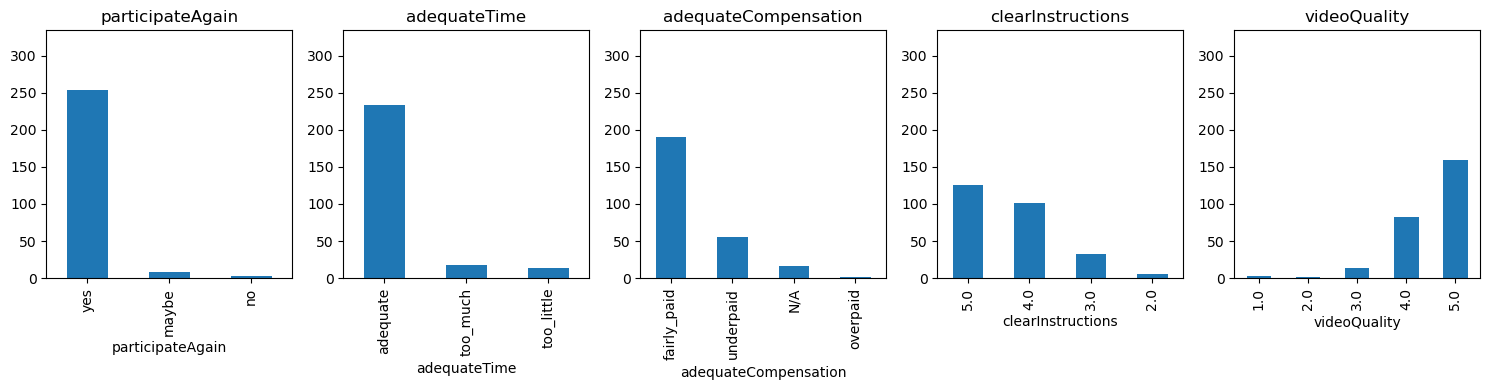

In [3]:
# [plot-qc]
# Sanity check: QC responses across the sample
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
qc_fields = ["participateAgain", "adequateTime", "adequateCompensation", "clearInstructions", "videoQuality"]
for ax, field in zip(axes, qc_fields):
    if field in QC.columns:
        if field == "videoQuality":
            QC[field].replace("NA", np.nan).dropna().astype(float).value_counts().sort_index().plot(
                kind="bar", ax=ax, title=field
            )
        else:
            QC[field].value_counts().plot(kind="bar", ax=ax, title=field)
        ax.set_ylim(0, len(QC))
plt.tight_layout()
plt.show()

In [4]:
# [exclusions]
# Apply preregistered exclusions (item 6 of prereg).
# We exclude groups where:
#   1) any participant non-participation in Discussion Stage (num_reports >= 3 = >1 report)
#   2) any participant drops out before all rounds complete (missing recall)
#   3) [reviewed manually for cheating — flag IDs here as needed]

# Manual flags from video / open-response review (none were applied in this study).
flagged_groups = []
n_before = all_data["gameId"].nunique()
all_data = all_data[~all_data["gameId"].isin(flagged_groups)]
print(f"After manual flags: {all_data['gameId'].nunique()} groups (was {n_before})")

# (1) Drop participants reported as not participating
all_data = all_data[all_data["num_reports"] < 3]
print(f"After participation filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# (2) Drop participants who left too many recall responses blank
# Prereg: a group is excluded if either participant leaves more than 2 recall responses
# blank in any single round. Recall rounds 2, 3, 4 each have 8 items.
recall_round_cols = {
    r: [c for c in recall.columns if c.startswith(f"recall_{r}_")] for r in ["1a", "1b", "1c", "2", "3", "4"]
}
def too_many_blanks(participant_row):
    for r, cols in recall_round_cols.items():
        if r in ("1a", "1b"):  # earlier rounds have <8 items, skip the >2 rule
            continue
        n_blank = sum(participant_row[c] == "" for c in cols if c in participant_row)
        if n_blank > 2:
            return True
    return False

mask_blank = all_data.apply(too_many_blanks, axis=1)
print(f"  participants with >2 blanks in any round: {mask_blank.sum()}")
bad_games = all_data.loc[mask_blank, "gameId"].unique()
all_data = all_data[~all_data["gameId"].isin(bad_games)]
print(f"After recall-blank filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# Keep only complete pairs (both participants have all R3 + R4 data)
pair_complete = (
    all_data.groupby("gameId")[["accuracy_3", "accuracy_4"]].count() == 2
).all(axis=1)
all_data = all_data[all_data["gameId"].isin(pair_complete[pair_complete].index)]
print(f"After complete-pairs filter: {all_data['gameId'].nunique()} groups, {len(all_data)} participants")

# Sanity: no mixed treatments within a gameId
treatment_counts = all_data.groupby("gameId")["treatment"].nunique()
assert treatment_counts.max() == 1, "Mixed treatments within a gameId"

print("\nFinal counts by treatment:")
print(all_data.groupby("treatment")["sampleId"].count())

After manual flags: 167 groups (was 167)
After participation filter: 166 groups, 318 participants
  participants with >2 blanks in any round: 33
After recall-blank filter: 140 groups, 279 participants
After complete-pairs filter: 139 groups, 278 participants

Final counts by treatment:
treatment
nonschema             70
nonschema_tangrams    70
schema                70
schema_tangrams       68
Name: sampleId, dtype: int64


In [5]:
# [aggregate-to-groups]
# Collapse to one row per group (accuracy is identical within a group; labeling time = max).
acc_cols = [c for c in all_data.columns if c.startswith("accuracy_")]
time_cols = [c for c in all_data.columns if c.startswith("time_labeling_")]

# Verify accuracy is identical within each (treatment, gameId)
assert all_data.groupby(["treatment", "gameId"])[acc_cols].std().max().max() == 0

data = (
    all_data.groupby(["treatment", "treatmentGroup", "changeType", "gameId"], as_index=False)
    [acc_cols + time_cols].max()
)
print(f"Group-level dataset: {len(data)} groups")
print()
print("Cell counts:")
print(data.groupby(["treatmentGroup", "changeType"])["gameId"].count().rename(index=COND_LABELS))
print()
print("Mean R4 accuracy by cell:")
print(data.groupby(["treatmentGroup", "changeType"])["accuracy_4"].mean().round(2).rename(index=COND_LABELS))

Group-level dataset: 139 groups

Cell counts:
treatmentGroup  changeType              
Non-schema      Ambiguously Incompatible    35
                Obviously Incompatible      35
Schema          Ambiguously Incompatible    35
                Obviously Incompatible      34
Name: gameId, dtype: int64

Mean R4 accuracy by cell:
treatmentGroup  changeType              
Non-schema      Ambiguously Incompatible    7.23
                Obviously Incompatible      6.11
Schema          Ambiguously Incompatible    5.83
                Obviously Incompatible      5.18
Name: accuracy_4, dtype: float64


## CONSORT participant flow

Dyad/participant counts at each exclusion step for the 2×2 design, rendered as a
CONSORT-style flow diagram (`figures/figureS5.pdf`). Self-contained:
re-derives the cascade from raw data so the numbers always match the
`[load-data]` / `[exclusions]` filters above.

CONSORT funnel: {'started': 430, 'not_consented': 8, 'no_intro': 81, 'no_partner': 7, 'randomized': {'part': 334, 'dyads': 167, 'cells': {('nonschema', 'ambiguous'): 40, ('nonschema', 'incompatible'): 41, ('schema', 'ambiguous'): 43, ('schema', 'incompatible'): 43}}, 'analyzed': {'part': 278, 'dyads': 139, 'cells': {('nonschema', 'ambiguous'): 35, ('nonschema', 'incompatible'): 35, ('schema', 'ambiguous'): 35, ('schema', 'incompatible'): 34}}}
Saved figures/figureS5.pdf and figures/figureS5.png


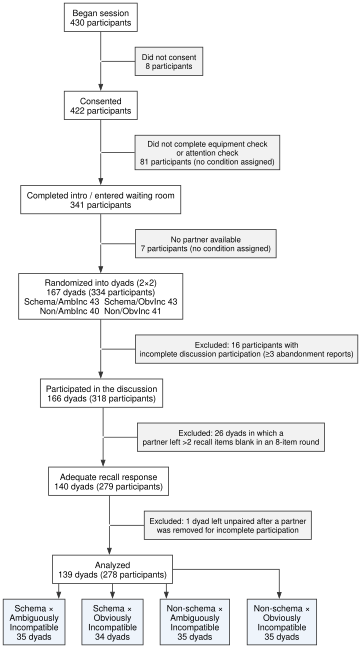

In [6]:
# [consort]
# CONSORT-style participant-flow diagram for Study 2 (2×2: schema/non-schema ×
# ambiguous/incompatible). Self-contained: re-derives the enrollment funnel +
# exclusion cascade from raw data (prefixes vars with _), mirroring the
# [load-data]/[exclusions] cells, then renders a vector PDF (+PNG) via
# analysis/consort.py. Keep in sync with those cells.
import glob as _glob, json as _json
from consort import consort_diagram

_FLAGGED = []  # manual cheating/communication flags; mirrors the [exclusions] cell

# Load ALL session records (including never-randomized ones) for the enrollment funnel.
_raw_all = []
for _fn in sorted(_glob.glob("../data/study*2/batch_*.scienceData.jsonl")):
    for _line in open(_fn):
        _raw_all.append(_json.loads(_line))
_raw = [r for r in _raw_all if r["sampleId"] != "missing"]  # randomized into a dyad

# Enrollment funnel (pre-randomization). Never-randomized records have sampleId=="missing",
# no gameId, treatment=="missing"; consent is a list of agreed items when given.
# playerIntroDone is set when a participant finishes the intro sequence (equipment
# check, attention check, instructions) and enters the waiting room; absence means
# they dropped during intro. gameStarted is never set for unmatched participants.
_started = len(_raw_all)
_not_consented = sum(1 for r in _raw_all if not isinstance(r.get("consent"), list))
_unmatched = [r for r in _raw_all
              if isinstance(r.get("consent"), list) and r.get("sampleId") == "missing"]
def _intro_done(r):
    return r.get("times", {}).get("playerIntroDone", "missing") != "missing"
_no_intro = sum(1 for r in _unmatched if not _intro_done(r))   # dropped during intro
_no_partner = sum(1 for r in _unmatched if _intro_done(r))     # completed intro, never matched
_consented = _started - _not_consented
_entered_lobby = _consented - _no_intro
assert _started == _not_consented + _no_intro + _no_partner + len(_raw)

_d = pd.DataFrame({
    "treatment": [r["treatment"]["name"] for r in _raw],
    "tg": [r["treatment"]["name"].split("_")[0] for r in _raw],
    "ct": ["incompatible" if "tangrams" in r["treatment"]["name"] else "ambiguous" for r in _raw],
    "gameId": [r["gameId"][-6:] for r in _raw],
    "num_reports": [len(r["reports"]) for r in _raw],
})
_rcl = pd.DataFrame([{k: v["value"].lower().strip()
                      for k, v in r["prompts"].items() if "recall" in k} for r in _raw])
_rcl.columns = [c.replace("prompt_recall_", "recall_") for c in _rcl.columns]
_rcl = _rcl[sorted(_rcl.columns)].fillna("")
_d = pd.concat([_d.reset_index(drop=True), _rcl.reset_index(drop=True)], axis=1)

_m = (_d.groupby("gameId")[_rcl.columns].nunique() == 1) & (_d.groupby("gameId")[_rcl.columns].count() == 2)
_m.columns = [c.replace("recall_", "match_") for c in _m.columns]
_d = pd.merge(_d, _m, left_on="gameId", right_index=True)
for _mc in [c for c in _d.columns if c.startswith("match_")]:
    _d[_mc.replace("match_", "matched_recall_")] = _d[_mc.replace("match_", "recall_")] * _d[_mc]
for _rd in ["3", "4"]:
    _cols = [c for c in _d.columns if f"matched_recall_{_rd}_" in c]
    _d[f"accuracy_{_rd}"] = _d[_cols].replace("", np.nan).nunique(axis=1).astype(float)

# preregistered recall-blank rule: >2 blanks in any single 8-item round (1c/2/3/4) -> drop dyad
_rrc = {_rr: [c for c in _rcl.columns if c.startswith(f"recall_{_rr}_")] for _rr in ["1c", "2", "3", "4"]}
def _too_many_blanks(row):
    return any(sum(row[c] == "" for c in cols) > 2 for cols in _rrc.values())

def _counts(x):
    return dict(part=len(x), dyads=x.gameId.nunique(),
                cells=x.groupby(["tg", "ct"]).gameId.nunique().to_dict())

# --- exclusion cascade (same order/criteria as [exclusions]) ---
_x = _d[~_d.gameId.isin(_FLAGGED)]
_s0 = _counts(_x)                                                       # randomized
_x = _x[_x["num_reports"] < 3]
_s1 = _counts(_x)                                                       # participated in discussion
_bad = _x.loc[_x.apply(_too_many_blanks, axis=1), "gameId"].unique()
_x = _x[~_x.gameId.isin(_bad)]
_s2 = _counts(_x)                                                       # adequate recall response
_pc = (_x.groupby("gameId")[["accuracy_3", "accuracy_4"]].count() == 2).all(axis=1)
_x = _x[_x.gameId.isin(_pc[_pc].index)]
_s3 = _counts(_x)                                                       # analyzed

# guard: final cascade must match the analyzed `data` table built above
assert _s3["dyads"] == data["gameId"].nunique(), "CONSORT total != analyzed sample"
print("CONSORT funnel:", {"started": _started, "not_consented": _not_consented,
                          "no_intro": _no_intro, "no_partner": _no_partner,
                          "randomized": _s0, "analyzed": _s3})

def _cellstr(c):
    return (f"Schema/AmbInc {c.get(('schema','ambiguous'),0)}  "
            f"Schema/ObvInc {c.get(('schema','incompatible'),0)}\n"
            f"Non/AmbInc {c.get(('nonschema','ambiguous'),0)}  "
            f"Non/ObvInc {c.get(('nonschema','incompatible'),0)}")

_stages = [
    f"Began session\n{_started} participants",
    f"Consented\n{_consented} participants",
    f"Completed intro / entered waiting room\n{_entered_lobby} participants",
    f"Randomized into dyads (2×2)\n{_s0['dyads']} dyads ({_s0['part']} participants)\n"
    + _cellstr(_s0["cells"]),
    f"Participated in the discussion\n{_s1['dyads']} dyads ({_s1['part']} participants)",
    f"Adequate recall response\n{_s2['dyads']} dyads ({_s2['part']} participants)",
    f"Analyzed\n{_s3['dyads']} dyads ({_s3['part']} participants)",
]
_exclusions = [
    f"Did not consent\n{_not_consented} participants",
    f"Did not complete equipment check\nor attention check\n"
    f"{_no_intro} participants (no condition assigned)",
    f"No partner available\n{_no_partner} participants (no condition assigned)",
    f"Excluded: {_s0['part'] - _s1['part']} participants with\nincomplete discussion "
    f"participation (≥3 abandonment reports)",
    f"Excluded: {_s1['dyads'] - _s2['dyads']} dyads in which a\npartner left >2 recall items "
    f"blank in an 8-item round",
    f"Excluded: {_s2['dyads'] - _s3['dyads']} dyad left unpaired after a partner\nwas removed for incomplete participation",
]
_c = _s3["cells"]
_arms = [
    f"Schema ×\nAmbiguously\nIncompatible\n{_c.get(('schema','ambiguous'),0)} dyads",
    f"Schema ×\nObviously\nIncompatible\n{_c.get(('schema','incompatible'),0)} dyads",
    f"Non-schema ×\nAmbiguously\nIncompatible\n{_c.get(('nonschema','ambiguous'),0)} dyads",
    f"Non-schema ×\nObviously\nIncompatible\n{_c.get(('nonschema','incompatible'),0)} dyads",
]

consort_diagram(_stages, _exclusions, _arms, path="figures/figureS5")


## Sample description (demographics)

Demographic summary of the analyzed sample, from the Demographics exit survey (retained in the released data). Education uses the `@watts-lab/surveys` coding; "bachelor's degree or higher" = codes 6–8 in both the US and UK scales. Education was only asked of US and UK residents, so it is summarized over the subset who answered.

In [7]:
# [demographics]
# Sample description for the analyzed sample (the participants in the final
# group-level `data`). Reads the Demographics exit survey from the released data.
# Education coding (@watts-lab/surveys): bachelor's or higher = codes 6,7,8 in BOTH
# the US and UK scales. Education is only asked of US/UK residents, so it is
# summarized over those who answered.
REF_YEAR = 2026
DEGREE_CODES = {"6", "7", "8"}

# demographics keyed by sampleId, parsed from the raw records
demographics = {}
for row in raw:
    for k, v in row.get("surveys", {}).items():
        if "Demographics" in k and isinstance(v, dict):
            demographics[row["sampleId"]] = v.get("responses") or {}

# restrict to the analyzed sample (participants whose group survived exclusions)
analyzed = all_data[all_data["gameId"].isin(data["gameId"])]
sample = [demographics.get(sid, {}) for sid in analyzed["sampleId"]]
n = len(sample)

gender = [d.get("gender") for d in sample if d.get("gender")]
n_female = sum(g == "female" for g in gender)

ages = np.array([REF_YEAR - int(d["birth_year"]) for d in sample
                 if str(d.get("birth_year", "")).isdigit()
                 and 1920 <= int(d["birth_year"]) <= REF_YEAR - 13], dtype=float)

edu = [d for d in sample if d.get("education_US") or d.get("education_UK")]
n_bachelor = sum((d.get("education_US") in DEGREE_CODES) or (d.get("education_UK") in DEGREE_CODES)
                 for d in edu)

print(f"Analyzed sample: N = {n} participants ({analyzed['gameId'].nunique()} groups)")
print(f"  Female: {n_female}/{len(gender)} = {100 * n_female / len(gender):.1f}%  (of those reporting gender)")
print(f"  Age:    mean {ages.mean():.1f}, SD {ages.std(ddof=1):.1f}  (n = {len(ages)})")
print(f"  Education reported (US/UK residents): {len(edu)}/{n} ({100 * len(edu) / n:.0f}% of sample)")
print(f"    Bachelor's degree or higher: {n_bachelor}/{len(edu)} = {100 * n_bachelor / len(edu):.1f}% (of those reporting)")


Analyzed sample: N = 278 participants (139 groups)
  Female: 132/278 = 47.5%  (of those reporting gender)
  Age:    mean 35.1, SD 10.8  (n = 278)
  Education reported (US/UK residents): 156/278 (56% of sample)
    Bachelor's degree or higher: 93/156 = 59.6% (of those reporting)


## Step 0 — Generating the human-coding materials (run once, upstream)

These cells turn the R4 recall labels into the materials the human coders worked from:
a flat coding sheet, the per-task Stagebook stimulus files, and the annotator task
template. They are **upstream** of everything in the H1 section below — coders worked
from these materials, and their returned judgements (`r4_label_coding_annotations_wide.csv`)
are what the schema-use aggregation reads. They are placed here so the notebook reads in
pipeline order, but they **write files and one cell deletes/rebuilds the stimuli
directory**, so they are gated behind `REGENERATE_CODING_MATERIALS` (default `False`):
a normal top-to-bottom run skips them and leaves the committed materials untouched. Flip
the switch only to regenerate the coding inputs.

In [8]:
# [coding-materials-config]
# Master switch for the run-once coding-material generation below. Kept False so a
# full "Run All" never wipes or rebuilds the committed Stagebook stimuli / coding sheet.
# Set True only when you intend to (re)generate them.
REGENERATE_CODING_MATERIALS = False

### Export labels for human coding

Per prereg item 3, schema-use coding is performed on **recall-stage** labels, not the
discussion-stage labels. This cell exports R4 recall labels in a long-form CSV ready
for three independent coders (one column per coder; aggregate via majority vote per
the prereg).

Each row = one (participant, image) judgement. For each row, the coder marks whether
the participant's R4 recall label for that image is schema-based. Context columns
show the same participant's earlier recall labels (R1c, R2, R3) and the partner's
R3 labels, so the coder can infer the schema the group adopted.

Only Schema-condition groups are exported (the prereg H1 test only requires coding
within the Schema arm); Non-Schema groups can be included for descriptive purposes by
dropping the `treatmentGroup == "schema"` filter.

In [9]:
# [export-labels-for-coding]
# Run-once data generation, gated by REGENERATE_CODING_MATERIALS (set above).
REGENERATE_CODING_MATERIALS = globals().get("REGENERATE_CODING_MATERIALS", False)
if not REGENERATE_CODING_MATERIALS:
    print("[skipped] export-labels-for-coding — set REGENERATE_CODING_MATERIALS=True to (re)generate.")
else:
    # Build long-form coding sheet from participant-level recall responses.
    #
    # Output: one row per (gameId, position, image_index) for R4 in Schema-condition groups.
    # Fields:
    #   - identifiers and condition
    #   - label_r4_self / label_r4_partner   (the labels to be considered)
    #   - context_r1c_self / r2_self / r3_self  (this participant's prior recall labels)
    #   - context_r3_partner                  (partner's R3 recall labels)
    #   - three blank coder columns + a notes column

    recall_round_sizes = {"1a": 2, "1b": 4, "1c": 8, "2": 8, "3": 8, "4": 8}
    recall_cols_by_round = {
        r: [f"recall_{r}_{i}" for i in range(n)] for r, n in recall_round_sizes.items()
    }

    # Participant-level recall lookup: gameId -> position -> round -> [labels]
    participant_recalls = {}
    participant_meta = {}
    for _, row in all_data[all_data["treatmentGroup"] == "schema"].iterrows():
        gid = row["gameId"]
        pos = row["position"]
        participant_recalls.setdefault(gid, {})[pos] = {
            r: [row.get(col, "") for col in cols] for r, cols in recall_cols_by_round.items()
        }
        participant_meta.setdefault(gid, {
            "treatment": row["treatment"],
            "changeType": row["changeType"],
        })

    coding_rows = []
    for gid, parts in participant_recalls.items():
        positions = sorted(parts.keys())
        if len(positions) != 2:
            continue  # only complete pairs
        meta = participant_meta[gid]
        for self_pos in positions:
            partner_pos = [p for p in positions if p != self_pos][0]
            self_recalls = parts[self_pos]
            partner_recalls = parts[partner_pos]
            for i in range(8):
                coding_rows.append({
                    "gameId": gid,
                    "treatment": meta["treatment"],
                    "changeType": meta["changeType"],
                    "position": self_pos,
                    "image_index": i,
                    "label_r4_self": self_recalls["4"][i],
                    "label_r4_partner": partner_recalls["4"][i],
                    "context_r1c_self": "; ".join(self_recalls["1c"]),
                    "context_r2_self":  "; ".join(self_recalls["2"]),
                    "context_r3_self":  "; ".join(self_recalls["3"]),
                    "context_r3_partner": "; ".join(partner_recalls["3"]),
                    "coder_1_schema_based": "",
                    "coder_2_schema_based": "",
                    "coder_3_schema_based": "",
                    "notes": "",
                })

    coding_df = pd.DataFrame(coding_rows).sort_values(["gameId", "position", "image_index"]).reset_index(drop=True)

    print(f"Exported {len(coding_df)} rows for coding")
    print(f"  Schema-condition groups: {coding_df['gameId'].nunique()}")
    print(f"  Rows per group: {coding_df.groupby('gameId').size().unique()}")
    print(f"  Treatments: {coding_df.groupby(['treatment', 'changeType']).size().to_dict()}")

    out_path = "../data/study_2/r4_labels_for_coding.csv"
    coding_df.to_csv(out_path, index=False)
    print(f"\nWrote to {out_path}")

    # Preview
    coding_df.head(3)

[skipped] export-labels-for-coding — set REGENERATE_CODING_MATERIALS=True to (re)generate.


### Export R4 labels for crowdworker coding (Stagebook annotator workflow)

The cell above writes a flat CSV for offline coding. The cell below generates the per-task stimulus markdown files for the Stagebook annotator workflow at `stagebook/annotation/r4_label_coding/`, plus a tasks-index CSV that maps each (gameId, position) to the prompt files it needs.

Each task = one participant's eight Round 4 labels. The annotator sees that participant's R1c–R3 recall labels and the partner's R3 labels for context, then classifies each R4 label as one of {One-off label, Systematic label, Can't tell / Neither}.

Both Schema and Non-Schema groups are exported; R4 labels only. Replication count and which subset to send to crowdworkers are handled at the annotator-project setup level, not in this workflow.

In [10]:
# [export-r4-label-coding-stimuli]
# Run-once data generation, gated by REGENERATE_CODING_MATERIALS (set above).
REGENERATE_CODING_MATERIALS = globals().get("REGENERATE_CODING_MATERIALS", False)
if not REGENERATE_CODING_MATERIALS:
    print("[skipped] export-r4-label-coding-stimuli — set REGENERATE_CODING_MATERIALS=True to (re)generate.")
else:
    # Generate per-task stimulus prompt files for the stagebook workflow at
    # stagebook/annotation/r4_label_coding/.
    # Per task (one row per gameId x position): 9 files
    #   - {gameId}_p{position}.context.prompt.md       (4x2 R4-only grid, shown once)
    #   - {gameId}_p{position}.label_{1..8}.prompt.md  (multipleChoice; just the
    #     specific label + the three classification options)
    # Plus a tasks-index CSV that lists contextFile and labelFile1..labelFile8
    # for each task, ready to feed into the annotator project as task fields.

    import os
    import shutil

    stimuli_dir = "../stagebook/annotation/r4_label_coding/stimuli"
    tasks_csv_path = "../data/study_2/r4_label_coding_tasks.csv"

    # Wipe previously generated stimuli so we never leave orphans behind
    if os.path.exists(stimuli_dir):
        shutil.rmtree(stimuli_dir)
    os.makedirs(stimuli_dir, exist_ok=True)

    # Pull R4 recall labels per (gameId, position)
    recall_cols_r4 = [f"recall_4_{i}" for i in range(8)]

    participant_r4 = {}
    participant_meta = {}
    for _, row in all_data.iterrows():
        gid = row["gameId"]
        pos = int(row["position"])
        participant_r4.setdefault(gid, {})[pos] = [row.get(col, "") for col in recall_cols_r4]
        participant_meta.setdefault(gid, {
            "treatment": row["treatment"],
            "treatmentGroup": row["treatmentGroup"],
            "changeType": row["changeType"],
        })


    def _clean(lbl):
        return "" if lbl is None else str(lbl).strip()


    def grid_cell(lbl, i):
        """Render `i. <label>` for a md table cell. Empty when the label is
        missing (no ∅ placeholder). Escape pipes/newlines."""
        s = _clean(lbl)
        if s == "":
            return ""
        display = s.replace("|", "\\|").replace("\n", " ").replace("\r", " ")
        return f"{i}. {display}"


    def quote_label(lbl):
        s = _clean(lbl)
        return "(no response)" if s == "" else s


    def write_file(path, lines):
        with open(path, "w") as f:
            f.write("\n".join(lines).rstrip() + "\n")


    task_rows = []
    for gid in sorted(participant_r4.keys()):
        positions = sorted(participant_r4[gid].keys())
        if len(positions) != 2:
            continue  # only complete pairs

        meta = participant_meta[gid]
        for self_pos in positions:
            r4_labels = participant_r4[gid][self_pos]

            # Shared 4x2 grid. Both rows render at the same weight (neither
            # row uses ** bolding) so the two rows are visually consistent.
            top = "| " + " | ".join(grid_cell(r4_labels[i], i + 1) for i in range(4)) + " |"
            sep = "| --- | --- | --- | --- |"
            bot = "| " + " | ".join(grid_cell(r4_labels[i], i + 1) for i in range(4, 8)) + " |"

            ctx = [
                "---",
                "type: noResponse",
                "---",
                "",
                "### Round 4 labels",
                "",
                top,
                sep,
                bot,
            ]
            ctx_filename = f"{gid}_p{self_pos}.context.prompt.md"
            write_file(os.path.join(stimuli_dir, ctx_filename), ctx)

            # Per-label files: just the specific label + the multipleChoice.
            label_files = []
            for i in range(1, 9):
                specific = quote_label(r4_labels[i - 1])
                lines = [
                    "---",
                    "type: multipleChoice",
                    "---",
                    "",
                    f"### Label {i}",
                    "",
                    "How would you classify this label?",
                    "",
                    f"> **{specific}**",
                    "",
                    "---",
                    "",
                    "- One-off label",
                    "- Systematic label",
                    "- Can't tell / Neither",
                ]
                lf_filename = f"{gid}_p{self_pos}.label_{i}.prompt.md"
                write_file(os.path.join(stimuli_dir, lf_filename), lines)
                label_files.append(f"stimuli/{lf_filename}")

            task_row = {
                "gameId": gid,
                "position": self_pos,
                "treatment": meta["treatment"],
                "treatmentGroup": meta["treatmentGroup"],
                "changeType": meta["changeType"],
                "contextFile": f"stimuli/{ctx_filename}",
            }
            for i, lf in enumerate(label_files, start=1):
                task_row[f"labelFile{i}"] = lf
            task_rows.append(task_row)

    tasks_df = pd.DataFrame(task_rows)
    os.makedirs(os.path.dirname(tasks_csv_path), exist_ok=True)
    tasks_df.to_csv(tasks_csv_path, index=False)

    print(f"Wrote {len(task_rows)} tasks ({len(task_rows) * 9} stimulus files) to {stimuli_dir}/")
    print(f"Wrote tasks index to {tasks_csv_path}")
    print("\nTasks per (treatmentGroup, changeType):")
    print(tasks_df.groupby(["treatmentGroup", "changeType"]).size())
    tasks_df.head(3)


[skipped] export-r4-label-coding-stimuli — set REGENERATE_CODING_MATERIALS=True to (re)generate.


In [11]:
# [populate-r4-label-coding-task-template]
# Run-once data generation, gated by REGENERATE_CODING_MATERIALS (set above).
REGENERATE_CODING_MATERIALS = globals().get("REGENERATE_CODING_MATERIALS", False)
if not REGENERATE_CODING_MATERIALS:
    print("[skipped] populate-r4-label-coding-task-template — set REGENERATE_CODING_MATERIALS=True to (re)generate.")
else:
    # Populate the Stagebook annotator task template with one entry per
    # (gameId, position) — i.e. one task per participant's round 4. Uses
    # tasks_df built by the cell above; binds the contextFile + 8 labelFile
    # fields used by the r4_label_coding treatment. exportPath is stable per
    # task so re-runs don't churn artifact filenames.

    import json

    template_path = "../stagebook/annotation/r4_label_coding/task-template_study-2-label-classification-test_2026-05-25.json"

    entries = []
    for row in tasks_df.itertuples(index=False):
        entries.append({
            "treatment": "r4_label_coding",
            "fields": {
                "contextFile": row.contextFile,
                "labelFile1": row.labelFile1,
                "labelFile2": row.labelFile2,
                "labelFile3": row.labelFile3,
                "labelFile4": row.labelFile4,
                "labelFile5": row.labelFile5,
                "labelFile6": row.labelFile6,
                "labelFile7": row.labelFile7,
                "labelFile8": row.labelFile8,
            },
            "exportPath": f"{row.gameId}_p{row.position}",
            "targetReplications": 3,
        })

    with open(template_path, "w") as f:
        json.dump(entries, f, indent=2)
        f.write("\n")

    print(f"Wrote {len(entries)} entries to {template_path}")


[skipped] populate-r4-label-coding-task-template — set REGENERATE_CODING_MATERIALS=True to (re)generate.


# Preregistered analysis (H1)

One-tailed Fisher's exact test on the proportion of Schema-condition groups that *use a schema* in R4, comparing Ambiguously Incompatible vs. Obviously Incompatible change.

**Required input.** Per-group binary indicator `schema_use_4` (1 if all members used schema-based names for > 4 of the 8 R4 images, 0 otherwise), derived from human coding of R4 recall labels. Three independent coders, majority vote per image.

The cell immediately below this paragraph (`[schema-use-coding-aggregation]`) builds the required `data/study_2/schema_use_coding.csv` from the human-annotated label data at `data/study_2/r4_label_coding_annotations_wide.csv`. The Fisher's exact cell after that reads the CSV. If the annotations file is missing, both cells print a stub and skip.


In [12]:
# [schema-use-coding-aggregation]
# Build schema_use_coding.csv from the human-annotated R4 labels.
# Per prereg item 3: "A group is coded as using a schema in a round if all members
# used schema-based names for > half of the 8 images." Operationalized as:
#   - per-item: majority vote among annotators (Systematic / One-off / Can't tell / tied)
#   - per-individual: schema_user = 1 iff > 4 of 8 items have Systematic majority
#   - per-group:      schema_use_4 = 1 iff ALL members of the dyad are schema_users

import os
from collections import Counter

ann_path = "../data/study_2/r4_label_coding_annotations_wide.csv"
out_path = "../data/study_2/schema_use_coding.csv"

if not os.path.exists(ann_path):
    print(f"[STUB] No annotations found at {ann_path}.")
    print(f"       Run the [export-r4-label-coding-stimuli] cell, collect annotations,")
    print(f"       then re-run this cell to build {out_path}.")
else:
    ann_df = pd.read_csv(ann_path)
    id_cols = ['gameId', 'position', 'label_idx', 'label_text']
    ann_cols = [c for c in ann_df.columns if c not in id_cols]
    print(f"Loaded {len(ann_df)} items rated by {len(ann_cols)} annotators")

    # --- Item-level majority (unique-mode rule; ties → None) ---
    def item_majority(row_vals):
        vals = [v for v in row_vals if isinstance(v, str) and v]
        if not vals: return None
        c = Counter(vals); top = c.most_common(1)[0][1]
        winners = [k for k, v in c.items() if v == top]
        return winners[0] if len(winners) == 1 else None

    ann_df['item_majority'] = ann_df[ann_cols].apply(lambda r: item_majority(r.values), axis=1)
    print(f"Item majorities: {ann_df['item_majority'].value_counts(dropna=False).to_dict()}")

    # --- Per-individual schema_user: > 4 of 8 items with Systematic majority ---
    indiv = (ann_df.groupby(['gameId', 'position'])['item_majority']
                   .apply(lambda s: int((s == 'Systematic label').sum() > 4))
                   .reset_index(name='schema_user_indiv'))
    print(f"\nPer-individual schema_user counts: {indiv['schema_user_indiv'].value_counts().to_dict()}")

    # --- Per-group schema_use_4: BOTH dyad members are schema_users ---
    group = (indiv.groupby('gameId')['schema_user_indiv']
                  .agg(n_users='sum', n_indivs='count')
                  .reset_index())
    group['schema_use_4'] = (
        (group['n_users'] == group['n_indivs']) & (group['n_indivs'] >= 2)
    ).astype(int)

    n_total = len(group)
    n_users = int(group['schema_use_4'].sum())
    n_partial = int(((group['n_indivs'] >= 2) & (group['n_users'] > 0) & (group['schema_use_4'] == 0)).sum())
    n_solo = int((group['n_indivs'] < 2).sum())
    print(f"\nPer-group schema_use_4 (BOTH members schema-users):")
    print(f"  schema_use_4 = 1: {n_users} groups (both members above threshold)")
    print(f"  schema_use_4 = 0: {n_total - n_users} groups")
    print(f"    of which {n_partial} had exactly one schema-using member (mixed dyads)")
    print(f"    of which {n_solo} had < 2 rated individuals (treated as 0)")

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    group[['gameId', 'schema_use_4']].to_csv(out_path, index=False)
    print(f"\nWrote {out_path} ({n_total} groups)")

    # Quick cross-tab against treatment for sanity (the Fisher's test below restricts to Schema arm)
    if 'data' in dir() and 'treatment' in data.columns:
        ck = data[['gameId', 'treatment', 'treatmentGroup', 'changeType']].merge(
            group[['gameId', 'schema_use_4']], on='gameId', how='inner'
        )
        print("\nSchema use × (treatmentGroup, changeType):")
        print(pd.crosstab([ck['treatmentGroup'].map(GROUP_LABELS), ck['changeType'].map(CHANGE_LABELS)], ck['schema_use_4'], margins=True))


Loaded 2216 items rated by 171 annotators
Item majorities: {'One-off label': 1274, 'Systematic label': 632, None: 172, "Can't tell / Neither": 138}

Per-individual schema_user counts: {0: 205, 1: 72}

Per-group schema_use_4 (BOTH members schema-users):
  schema_use_4 = 1: 27 groups (both members above threshold)
  schema_use_4 = 0: 112 groups
    of which 18 had exactly one schema-using member (mixed dyads)
    of which 1 had < 2 rated individuals (treated as 0)

Wrote ../data/study_2/schema_use_coding.csv (139 groups)

Schema use × (treatmentGroup, changeType):
schema_use_4                               0   1  All
treatmentGroup changeType                            
Non-schema     Ambiguously Incompatible   33   2   35
               Obviously Incompatible     35   0   35
Schema         Ambiguously Incompatible   13  22   35
               Obviously Incompatible     31   3   34
All                                      112  27  139


## Inter-rater reliability of the schema-use coding

Reliability of the human label coding that feeds H1. Each R4 recall label was
classified by independent crowd coders as *Systematic* / *One-off* / *Can't tell*;
the schema-use DV uses the per-item majority.

H1 is a one-tailed Fisher's test **within the Schema arm**, so the reliability that
matters is the agreement on the items that actually enter the test: the Schema-arm
groups that survive exclusions (`data[treatmentGroup == "schema"]`). The annotation
set also contains Non-Schema groups, which were coded for descriptive purposes but
never enter H1; the cell reports the H1 subset and notes how many annotated groups
are set aside.

The rated set is uneven (most items drew three coders, but some drew more or fewer,
and coders are not fixed across items), so we report two complementary statistics:

- **Fleiss' \\(\\kappa\\)** on items rated by exactly three coders (the modal,
  majority-vote-relevant case), via `statsmodels`.
- **Krippendorff's \\(\\alpha\\)** (nominal) over *all* items rated by \\(\\ge 2\\) coders,
  which tolerates the variable number of coders per item. Implemented inline.

Both are reported for the three-category coding and for the binarized
*Systematic vs. not* collapse that H1 actually depends on.

In [13]:
# [annotation-irr]
# Inter-rater reliability of the R4 schema-use coding, scoped to the H1 test set.
# H1 is a one-tailed Fisher's test within the Schema arm, so we restrict the IRR to
# the Schema-arm groups that survive exclusions (the rows that enter the test) and
# report agreement on exactly those items. Non-Schema groups in the annotation file
# are coded for description only and are set aside here.
# Statistics: Fleiss' kappa (3-coder items, statsmodels) and Krippendorff's alpha
# (nominal, all >=2-coder items, inline), for the 3-category coding and the
# binarized "Systematic vs not" collapse H1 actually uses.
import os
from statsmodels.stats.inter_rater import fleiss_kappa

ann_path = "../data/study_2/r4_label_coding_annotations_wide.csv"
CATS = ["One-off label", "Systematic label", "Can't tell / Neither"]

def krippendorff_alpha_nominal(ratings, categories):
    """Nominal Krippendorff's alpha over a list of per-item rating lists.
    Items with < 2 ratings are ignored (they carry no (dis)agreement)."""
    idx = {c: i for i, c in enumerate(categories)}
    k = len(categories)
    o = np.zeros((k, k))  # coincidence matrix
    for vals in ratings:
        m = len(vals)
        if m < 2:
            continue
        cnt = np.bincount([idx[v] for v in vals], minlength=k).astype(float)
        for a in range(k):
            o[a, a] += cnt[a] * (cnt[a] - 1) / (m - 1)
            for b in range(k):
                if a != b:
                    o[a, b] += cnt[a] * cnt[b] / (m - 1)
    n_marg = o.sum(axis=1)
    n = o.sum()
    if n <= 1:
        return np.nan
    D_o = n - np.trace(o)                            # observed disagreement (nominal)
    D_e = (n ** 2 - (n_marg ** 2).sum()) / (n - 1)   # expected disagreement
    return 1.0 - D_o / D_e if D_e > 0 else np.nan

def fleiss_three(ratings, classes):
    """Fleiss' kappa on items rated by exactly 3 coders.
    `classes` maps a raw label to its collapsed class."""
    three = [v for v in ratings if len(v) == 3]
    cls = sorted({classes(c) for c in CATS})
    table = np.array([[sum(classes(v) == c for v in vals) for c in cls] for vals in three])
    return fleiss_kappa(table, method="fleiss"), len(three)

def report_irr(ann_df, ann_cols, label):
    ratings = ann_df[ann_cols].apply(
        lambda r: [v for v in r if isinstance(v, str) and v], axis=1
    ).tolist()
    n_per = np.array([len(v) for v in ratings])
    def pairwise_agreement(vals):
        m = len(vals)
        if m < 2:
            return np.nan
        agree = sum(vals[i] == vals[j] for i in range(m) for j in range(i + 1, m))
        return agree / (m * (m - 1) / 2)
    pa = np.nanmean([pairwise_agreement(v) for v in ratings if len(v) >= 2])
    k3, n3 = fleiss_three(ratings, classes=lambda c: c)
    a3 = krippendorff_alpha_nominal(ratings, CATS)
    BIN = ["Systematic", "Other"]
    binarize = lambda c: "Systematic" if c == "Systematic label" else "Other"
    kb, _ = fleiss_three(ratings, classes=binarize)
    ab = krippendorff_alpha_nominal([[binarize(v) for v in vals] for vals in ratings], BIN)
    print(f"--- {label} ---")
    print(f"  {len(ratings)} items, {int(n_per.sum())} ratings; per-item coders: " +
          ", ".join(f"{k}->{int((n_per == k).sum())}" for k in sorted(set(n_per))))
    print(f"  {n3} items with exactly 3 coders; mean pairwise agreement {pa * 100:.1f}%")
    print(f"  3-category coding:   Fleiss k (n=3) = {k3:6.3f}   Krippendorff a (>=2) = {a3:6.3f}")
    print(f"  Systematic vs not:   Fleiss k (n=3) = {kb:6.3f}   Krippendorff a (>=2) = {ab:6.3f}")

if not os.path.exists(ann_path):
    print(f"[STUB] No annotations found at {ann_path}; cannot compute IRR.")
else:
    ann_df = pd.read_csv(ann_path)
    id_cols = ["gameId", "position", "label_idx", "label_text"]
    ann_cols = [c for c in ann_df.columns if c not in id_cols]

    # H1 test set: Schema-arm groups that survive exclusions (these enter the Fisher test)
    if "data" in dir() and "treatmentGroup" in data.columns:
        h1_games = set(data.loc[data["treatmentGroup"] == "schema", "gameId"])
        ann_games = set(ann_df["gameId"])
        h1_df = ann_df[ann_df["gameId"].isin(h1_games)]
        n_h1 = len(h1_games & ann_games)
        n_missing = len(h1_games - ann_games)
        n_setaside = len(ann_games - h1_games)
        print(f"H1 test set: {len(h1_games)} Schema-arm groups survive exclusions; "
              f"{n_h1} are annotated, {n_missing} missing annotations.")
        print(f"Set aside (annotated but not in H1, i.e. Non-Schema): {n_setaside} groups.\n")
        report_irr(h1_df, ann_cols, "H1 subset (Schema-arm groups in the Fisher test)")
        print()
        report_irr(ann_df, ann_cols, "All annotated items (both arms; reference)")
    else:
        print("(`data` not in scope — run the pipeline above first; reporting all items.)\n")
        report_irr(ann_df, ann_cols, "All annotated items")

    print("\nGuide (Landis & Koch): <0 poor, 0-.20 slight, .21-.40 fair,")
    print("  .41-.60 moderate, .61-.80 substantial, .81-1 almost perfect.")


H1 test set: 69 Schema-arm groups survive exclusions; 69 are annotated, 0 missing annotations.
Set aside (annotated but not in H1, i.e. Non-Schema): 70 groups.

--- H1 subset (Schema-arm groups in the Fisher test) ---
  1096 items, 3256 ratings; per-item coders: 1->24, 2->48, 3->984, 4->24, 5->8, 6->8
  984 items with exactly 3 coders; mean pairwise agreement 63.3%
  3-category coding:   Fleiss k (n=3) =  0.395   Krippendorff a (>=2) =  0.402
  Systematic vs not:   Fleiss k (n=3) =  0.458   Krippendorff a (>=2) =  0.458

--- All annotated items (both arms; reference) ---
  2216 items, 6720 ratings; per-item coders: 1->56, 2->96, 3->1944, 4->40, 5->24, 6->32, 7->24
  1944 items with exactly 3 coders; mean pairwise agreement 63.3%
  3-category coding:   Fleiss k (n=3) =  0.376   Krippendorff a (>=2) =  0.368
  Systematic vs not:   Fleiss k (n=3) =  0.458   Krippendorff a (>=2) =  0.445

Guide (Landis & Koch): <0 poor, 0-.20 slight, .21-.40 fair,
  .41-.60 moderate, .61-.80 substantial, .

### Where does the disagreement come from? Coding diagnostics

Moderate \\(\\kappa\\) could mean either (a) some coders weren't doing the task, or
(b) the task itself is ill-defined. We separate these using signals the wide CSV
drops but the raw annotation JSONs retain:

- **Practice-item accuracy** — every coder first classified three labels with known
  answers; near-ceiling accuracy rules out widespread inattention.
- **Response time** — speeding (sub-second responses) would flag low-effort coding.
- **Leave-one-out agreement by category** — does disagreement concentrate in one
  category (a fuzzy boundary) or spread evenly (uniform noise)?
- **Definite-only agreement** and **"Can't tell" usage** — isolate the contested
  commit-vs-punt decision from the One-off / Systematic distinction itself.

Reads the raw JSONs in `../annotation/r4_label_coding/`; prints a stub if absent.

In [14]:
# [coding-diagnostics]
# Diagnose the source of moderate IRR: inattentive coders vs. genuine task ambiguity.
# Uses signals dropped from the wide CSV (practice accuracy, response time) plus
# leave-one-out agreement by category, read from the raw annotation JSONs.
import glob, re, os
from collections import Counter

ann_dir = "../annotation/r4_label_coding"
raw_files = sorted(f for f in glob.glob(os.path.join(ann_dir, "*.json"))
                   if not f.endswith(".sidecar.json"))

if not raw_files:
    print(f"[STUB] No raw annotation JSONs in {ann_dir}; skipping coding diagnostics.")
else:
    PRACTICE_GOLD = {"practice_1": "One-off label",
                     "practice_2": "Systematic label",
                     "practice_3": "One-off label"}
    CT = "Can't tell / Neither"

    rec, practice = [], []
    for fn in raw_files:
        d = json.load(open(fn))
        aid, resp = d["annotatorAnonymousId"], d["responses"]
        nc = nt = 0
        for pk, gold in PRACTICE_GOLD.items():
            r = resp.get("prompt_" + pk)
            if r and r.get("value"):
                nt += 1; nc += int(r["value"] == gold)
        practice.append({"aid": aid, "correct": nc, "answered": nt})
        # task labels, with per-item time = diff of cumulative stageTimeElapsed
        labs = []
        for k, v in resp.items():
            m = re.match(r"prompt_label_(\d+)_category$", k)
            if not m:
                continue
            mm = re.search(r"/([0-9A-Za-z]+)_p(\d+)\.label_(\d+)", v.get("file", ""))
            item = f"{mm.group(1)}_p{mm.group(2)}_{m.group(1)}" if mm else None
            labs.append((v.get("stageTimeElapsed", np.nan), item, v.get("value")))
        labs.sort(key=lambda x: x[0])
        prev = 0.0
        for t, item, val in labs:
            rec.append({"aid": aid, "item": item, "value": val, "dt": t - prev})
            prev = t
    rec = pd.DataFrame(rec)
    prc = pd.DataFrame(practice)

    # --- (1) Attention: practice accuracy + speed ---
    print("ATTENTION / EFFORT")
    print(f"  {len(prc)} coding sessions by {prc['aid'].nunique()} distinct coders "
          f"(coders repeat across HITs; practice re-administered each session)")
    print(f"  Practice accuracy (3 known-answer items/session): "
          f"{prc['correct'].value_counts().sort_index().to_dict()}  "
          f"(mean {(prc['correct']/prc['answered']).mean():.3f})")
    print(f"  Response time/item: median {rec['dt'].median():.1f}s, "
          f"IQR [{rec['dt'].quantile(.25):.1f}, {rec['dt'].quantile(.75):.1f}], "
          f"sub-1s {100*(rec['dt']<1).mean():.1f}% of responses")

    # --- (2) Item-level vote patterns (3-coder items) ---
    votes = rec.dropna(subset=["item"]).groupby("item")["value"].apply(list)
    aids  = rec.dropna(subset=["item"]).groupby("item")["aid"].apply(list)
    three = votes[votes.apply(len) == 3]
    def pat(v):
        cc = sorted(Counter(v).values(), reverse=True)
        return {(3,): "unanimous", (2, 1): "split 2-1", (1, 1, 1): "tied 1-1-1"}[tuple(cc)]
    print("\nITEM-LEVEL VOTE PATTERNS (3-coder items, n={})".format(len(three)))
    for k, c in three.apply(pat).value_counts().items():
        print(f"  {k:12s}: {c:5d}  ({100*c/len(three):4.1f}%)")

    # --- (3) Leave-one-out agreement, overall and by category ---
    loo = []
    for v, a in zip(votes, aids):
        if len(v) < 3:
            continue
        for i in range(len(v)):
            others = Counter(v[:i] + v[i+1:])
            top = others.most_common(1)[0][1]
            winners = [k for k, cc in others.items() if cc == top]
            loo.append((a[i], v[i], int(v[i] in winners and len(winners) == 1)))
    loo = pd.DataFrame(loo, columns=["aid", "value", "agree"])
    per = loo.groupby("aid")["agree"].mean()
    import math
    p_bar = loo["agree"].mean()
    exp_sd = math.sqrt(p_bar * (1 - p_bar) * (1 / loo.groupby("aid").size()).mean())
    print("\nLEAVE-ONE-OUT AGREEMENT (with the other coders' majority)")
    print(f"  Overall: {p_bar:.3f}")
    print("  By the coder's own choice:")
    for val, g in loo.groupby("value"):
        print(f"    {val:22s}: {g['agree'].mean():.3f}  (n={len(g)})")
    print(f"  Between-coder spread: sd {per.std():.3f} vs {exp_sd:.3f} expected by "
          f"chance ({per.std()/exp_sd:.1f}x) -> real coder heterogeneity")

    # --- (4) Isolate the fuzzy middle: definite-only agreement + punt rate ---
    def definite_agree(v):
        vv = [x for x in v if x != CT]
        return Counter(vv).most_common(1)[0][1] / len(vv) if len(vv) >= 2 else np.nan
    ct_rate = rec.assign(ct=rec["value"].eq(CT)).groupby("aid")["ct"].mean()
    print("\nTHE FUZZY MIDDLE ('Can't tell')")
    print(f"  Within-item agreement among DEFINITE votes only: "
          f"{three.apply(definite_agree).mean():.3f}")
    print(f"  'Can't tell' usage: {100*rec['value'].eq(CT).mean():.1f}% of votes; "
          f"per-coder median {100*ct_rate.median():.1f}%, max {100*ct_rate.max():.0f}%")
    print(f"  Corr(coder agreement, coder punt-rate): "
          f"r = {per.reindex(ct_rate.index).corr(ct_rate):.3f}")

    print("\nSummary: practice accuracy is near-ceiling and disagreement is "
          "independent of response time; disagreement concentrates in the "
          "'Can't tell' category, while the One-off/Systematic distinction shows "
          "high definite-only agreement.")


ATTENTION / EFFORT
  840 coding sessions by 171 distinct coders (coders repeat across HITs; practice re-administered each session)
  Practice accuracy (3 known-answer items/session): {2: 20, 3: 820}  (mean 0.992)
  Response time/item: median 2.0s, IQR [1.3, 4.3], sub-1s 8.5% of responses

ITEM-LEVEL VOTE PATTERNS (3-coder items, n=1944)
  unanimous   :   950  (48.9%)
  split 2-1   :   880  (45.3%)
  tied 1-1-1  :   114  ( 5.9%)

LEAVE-ONE-OUT AGREEMENT (with the other coders' majority)
  Overall: 0.512
  By the coder's own choice:
    Can't tell / Neither  : 0.100  (n=801)
    One-off label         : 0.607  (n=3571)
    Systematic label      : 0.508  (n=2100)
  Between-coder spread: sd 0.205 vs 0.084 expected by chance (2.4x) -> real coder heterogeneity

THE FUZZY MIDDLE ('Can't tell')
  Within-item agreement among DEFINITE votes only: 0.887
  'Can't tell' usage: 12.5% of votes; per-coder median 7.5%, max 78%
  Corr(coder agreement, coder punt-rate): r = -0.391

Summary: practice accur

In [15]:
# [prereg-h1-fishers-exact]
# Preregistered primary analysis: one-tailed Fisher's exact test on R4 schema use,
# Schema × Ambiguously Incompatible vs Schema × Obviously Incompatible.
import os
from scipy.stats import fisher_exact

coding_path = "../data/study_2/schema_use_coding.csv"

if not os.path.exists(coding_path):
    print(f"[STUB] No schema-use coding found at {coding_path}.")
    print("       Once three coders have labeled R4 schema use per group, save a CSV with")
    print("       columns `gameId, schema_use_4` (1 if >4/8 images used schema-based names")
    print("       per the prereg majority-vote rule, else 0) and re-run this cell.")
else:
    coding = pd.read_csv(coding_path)
    assert set(coding.columns) >= {"gameId", "schema_use_4"}, "coding CSV needs gameId, schema_use_4"
    # Merge onto the group-level dataset
    schema_groups = data[data["treatmentGroup"] == "schema"].merge(
        coding[["gameId", "schema_use_4"]], on="gameId", how="left"
    )
    missing = schema_groups["schema_use_4"].isna().sum()
    if missing > 0:
        print(f"WARNING: {missing} Schema-condition groups missing schema-use coding")
        schema_groups = schema_groups.dropna(subset=["schema_use_4"])

    non_obvious = schema_groups[schema_groups["changeType"] == "ambiguous"]["schema_use_4"].astype(int)
    obvious     = schema_groups[schema_groups["changeType"] == "incompatible"]["schema_use_4"].astype(int)

    a, b = non_obvious.sum(), len(non_obvious) - non_obvious.sum()
    c, d = obvious.sum(),     len(obvious)     - obvious.sum()
    table = np.array([[a, b], [c, d]])

    print("R4 schema use (Schema condition only)")
    print("=" * 60)
    print(f"                                used schema  did not")
    print(f"  Ambiguously Incompatible  {a:>8d} {b:>10d}  (n={len(non_obvious)})")
    print(f"  Obviously Incompatible    {c:>8d} {d:>10d}  (n={len(obvious)})")

    odds_ratio, p_fisher = fisher_exact(table, alternative="greater")
    print(f"\nFisher's exact (one-tailed, Ambiguously > Obviously Incompatible):")
    print(f"  odds ratio = {odds_ratio:.3f}")
    print(f"  p          = {p_fisher:.4f}")
    print(f"\n  Decision rule: reject H0 if p < 0.05")

R4 schema use (Schema condition only)
                                used schema  did not
  Ambiguously Incompatible        22         13  (n=35)
  Obviously Incompatible           3         31  (n=34)

Fisher's exact (one-tailed, Ambiguously > Obviously Incompatible):
  odds ratio = 17.487
  p          = 0.0000

  Decision rule: reject H0 if p < 0.05


## Is H1 robust to the coding? Resampling the coders, not just measuring \\(\\kappa\\)

Per-coder agreement (Fleiss $(\kappa \approx 0.46)$, moderate) is a reliability
statistic for an *individual* coder's label. But H1 does not use individual labels:
the schema-use DV is a three-stage aggregate (per-item majority of three coders →
per-individual threshold of (>4/8) Systematic items → per-group conjunction of both
members). Independent coder noise partly cancels under that aggregation, so
$\kappa\$ *understates* the reliability of the quantity the test actually depends on.

The decision-relevant question is therefore not "how often do two coders agree?" but
"would a different panel of coders, and a different defensible coding rule, have
produced the same H1 conclusion?" We answer it two ways:

1. **Coder bootstrap.** For each label, resample its coder votes with replacement,
   recompute the per-item majority, propagate through the full aggregation, and re-run
   the one-tailed Fisher test. The spread of the resampled p-values / odds ratios
   is the uncertainty in H1 that the coding contributes.
2. **Decision-rule sensitivity.** Re-run H1 under a grid of item rules (plurality,
   unanimity, majority-among-definite-votes) × individual thresholds ((>3,4,5) of 8).


In [16]:
# [h1-coding-robustness]
# Confidence in H1 given the coding, via resampling the coders (not via kappa).
# H1's DV aggregates 3 coders -> individual threshold -> group conjunction, so the
# right confidence measure is the stability of the Fisher result under (1) bootstrap
# resampling of each item's coder votes and (2) alternative coding rules.
import os, math
from scipy.stats import fisher_exact

ann_path = "../data/study_2/r4_label_coding_annotations_wide.csv"
SYS, ONE, CT = "Systematic label", "One-off label", "Can't tell / Neither"
CATS = [SYS, ONE, CT]
N_BOOT = 5000

if not os.path.exists(ann_path) or "data" not in dir():
    print(f"[STUB] Needs {ann_path} and the group-level `data`; skipping robustness check.")
else:
    rng = np.random.default_rng(42)
    ann = pd.read_csv(ann_path)
    id_cols = ["gameId", "position", "label_idx", "label_text"]
    acols = [c for c in ann.columns if c not in id_cols]
    # per-item category counts [Systematic, One-off, Can't-tell]
    cnt = np.vstack(ann[acols].apply(
        lambda r: np.array([sum(v == c for v in r.values if isinstance(v, str)) for c in CATS], float),
        axis=1).values)

    # integer index structure for fast aggregation: item -> individual -> group
    indiv_code, indiv_keys = pd.factorize(pd.Series(list(zip(ann["gameId"], ann["position"]))))
    indiv_game = np.array([k[0] for k in indiv_keys])
    group_code, group_keys = pd.factorize(pd.Series(indiv_game))
    n_indiv, n_group = len(indiv_keys), len(group_keys)
    grp_count = np.bincount(group_code, minlength=n_group)
    # restrict to the H1 test set: Schema-arm groups that survive exclusions
    ct_map = (data[data["treatmentGroup"] == "schema"]
              .drop_duplicates("gameId").set_index("gameId")["changeType"].to_dict())
    grp_change = np.array([ct_map.get(g) for g in group_keys])
    amb_idx = np.where(grp_change == "ambiguous")[0]
    inc_idx = np.where(grp_change == "incompatible")[0]

    def fisher_from_sysitem(sys_item, thr=4):
        nsys = np.bincount(indiv_code, weights=sys_item, minlength=n_indiv)
        user = (nsys > thr).astype(float)
        gu = np.bincount(group_code, weights=user, minlength=n_group)
        su = ((gu == grp_count) & (grp_count >= 2)).astype(int)
        a, c = su[amb_idx].sum(), su[inc_idx].sum()
        orr, p = fisher_exact([[a, len(amb_idx) - a], [c, len(inc_idx) - c]], alternative="greater")
        return a, c, orr, p

    # baseline: per-item plurality (strict unique mode), ties -> not Systematic
    sys_base = ((cnt[:, 0] > cnt[:, 1]) & (cnt[:, 0] > cnt[:, 2])).astype(float)
    a0, c0, or0, p0 = fisher_from_sysitem(sys_base)
    print(f"Baseline H1 (plurality coding): Ambiguously Incompatible {a0}/{len(amb_idx)} vs "
          f"Obviously Incompatible {c0}/{len(inc_idx)} used schema; OR={or0:.1f}, one-tailed p={p0:.5f}\n")

    # (1) coder bootstrap. Each item's per-item Systematic call is, under resampling of
    # its votes, Bernoulli(p_sys) where p_sys = P(plurality==Systematic). Compute p_sys
    # exactly from the multinomial, then Monte-Carlo the downstream pipeline.
    def p_sys_resample(c):
        n = int(c.sum())
        if n == 0:
            return np.nan
        p = c / n
        tot = 0.0
        for a in range(n + 1):
            for b in range(n - a + 1):
                d = n - a - b
                if a > b and a > d:  # plurality strictly Systematic
                    tot += (math.factorial(n) / (math.factorial(a) * math.factorial(b) * math.factorial(d))
                            * p[0]**a * p[1]**b * p[2]**d)
        return tot
    p_sys = np.array([p_sys_resample(c) for c in cnt])
    draws = (rng.random((N_BOOT, len(p_sys))) < p_sys).astype(float)
    ps = np.empty(N_BOOT); ors = np.empty(N_BOOT)
    amb_u = np.empty(N_BOOT); inc_u = np.empty(N_BOOT)
    for i in range(N_BOOT):
        a, c, o, p = fisher_from_sysitem(draws[i])
        ps[i], ors[i], amb_u[i], inc_u[i] = p, o, a, c
    fin = ors[np.isfinite(ors)]
    pct = lambda x, q: np.percentile(x, q)
    print(f"(1) CODER BOOTSTRAP (B={N_BOOT}; resample each item's coders -> full pipeline -> Fisher)")
    print(f"    one-tailed p: median {np.median(ps):.4f}, 95% [{pct(ps,2.5):.4f}, {pct(ps,97.5):.4f}]")
    print(f"    H1 significant (p<.05) in {100*np.mean(ps<.05):.1f}% of resamples; p<.01 in {100*np.mean(ps<.01):.1f}%")
    print(f"    odds ratio: median {np.median(fin):.1f}, 95% [{pct(fin,2.5):.1f}, {pct(fin,97.5):.1f}]")
    print(f"    'used schema' counts: Ambiguously Incompatible {np.median(amb_u):.0f} [{pct(amb_u,2.5):.0f},{pct(amb_u,97.5):.0f}]/{len(amb_idx)}, "
          f"Obviously Incompatible {np.median(inc_u):.0f} [{pct(inc_u,2.5):.0f},{pct(inc_u,97.5):.0f}]/{len(inc_idx)}")

    # (2) decision-rule sensitivity grid
    rules = {
        "plurality (baseline)": lambda c: float(c[0] > c[1] and c[0] > c[2]),
        "unanimous-Systematic": lambda c: float(c[0] == c.sum() and c.sum() > 0),
        "definite-majority":    lambda c: float((c[0] + c[1]) > 0 and c[0] > c[1]),  # ignore Can't-tell
    }
    print(f"\n(2) DECISION-RULE SENSITIVITY (point-estimate coding)")
    print(f"    {'item rule':22s} {'indiv thr':9s}  amb   inc    p")
    for rn, rf in rules.items():
        si = np.array([rf(c) for c in cnt])
        for thr in (3, 4, 5):
            a, c, o, p = fisher_from_sysitem(si, thr=thr)
            print(f"    {rn:22s} >{thr}/8     {a:>3d}   {c:>3d}   {p:.4f}")

    print("\nSummary: per-coder agreement is moderate, but the aggregated schema-use "
          "DV is stable -- the H1 result holds in ~100% of coder bootstraps and under "
          "every coding rule tested, including unanimity.")


Baseline H1 (plurality coding): Ambiguously Incompatible 22/35 vs Obviously Incompatible 3/34 used schema; OR=17.5, one-tailed p=0.00000

(1) CODER BOOTSTRAP (B=5000; resample each item's coders -> full pipeline -> Fisher)
    one-tailed p: median 0.0000, 95% [0.0000, 0.0002]
    H1 significant (p<.05) in 100.0% of resamples; p<.01 in 100.0%
    odds ratio: median 15.5, 95% [8.7, 49.5]
    'used schema' counts: Ambiguously Incompatible 21 [19,23]/35, Obviously Incompatible 3 [1,5]/34

(2) DECISION-RULE SENSITIVITY (point-estimate coding)
    item rule              indiv thr  amb   inc    p
    plurality (baseline)   >3/8      22     4   0.0000
    plurality (baseline)   >4/8      22     3   0.0000
    plurality (baseline)   >5/8      22     2   0.0000
    unanimous-Systematic   >3/8      14     1   0.0001
    unanimous-Systematic   >4/8      12     1   0.0008
    unanimous-Systematic   >5/8      10     1   0.0037
    definite-majority      >3/8      25     5   0.0000
    definite-major

# Additional analyses

## Interaction contrast on R4 accuracy

`penalty(x) = mean(Schema, x) - mean(Non-Schema, x)`. Test whether
`penalty(Ambiguously Incompatible) − penalty(Obviously Incompatible) < 0` (one-tailed) using a restricted
permutation test: within each Schema condition, permute change-type labels across
groups, recompute the contrast, repeat 10,000 times.

In [17]:
# [h1-interaction-contrast]
np.random.seed(42)

def get_cell(tg, ct):
    return data[(data["treatmentGroup"] == tg) & (data["changeType"] == ct)]["accuracy_4"].values

schema_amb = get_cell("schema", "ambiguous")
schema_inc = get_cell("schema", "incompatible")
nonschema_amb = get_cell("nonschema", "ambiguous")
nonschema_inc = get_cell("nonschema", "incompatible")

print("Cell sizes:")
print(f"  Schema     × Ambiguously Incompatible: n={len(schema_amb):3d}  mean={schema_amb.mean():.2f}")
print(f"  Schema     × Obviously Incompatible:   n={len(schema_inc):3d}  mean={schema_inc.mean():.2f}")
print(f"  Non-schema × Ambiguously Incompatible: n={len(nonschema_amb):3d}  mean={nonschema_amb.mean():.2f}")
print(f"  Non-schema × Obviously Incompatible:   n={len(nonschema_inc):3d}  mean={nonschema_inc.mean():.2f}")

penalty_amb = schema_amb.mean() - nonschema_amb.mean()
penalty_inc = schema_inc.mean() - nonschema_inc.mean()
observed_contrast = penalty_amb - penalty_inc
print(f"\npenalty(Ambiguously Incompatible): {penalty_amb:+.3f}")
print(f"penalty(Obviously Incompatible):   {penalty_inc:+.3f}")
print(f"interaction contrast:  {observed_contrast:+.3f}")
print(f"  (negative = Ambiguously Incompatible penalty larger, supports H1)")

# Restricted permutation test: within each schema condition, shuffle change-type labels.
def restricted_perm_p(schema_amb, schema_inc, nonschema_amb, nonschema_inc, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    obs = (schema_amb.mean() - nonschema_amb.mean()) - (schema_inc.mean() - nonschema_inc.mean())
    schema_pool = np.concatenate([schema_amb, schema_inc])
    schema_split = len(schema_amb)
    ns_pool = np.concatenate([nonschema_amb, nonschema_inc])
    ns_split = len(nonschema_amb)
    perm_contrasts = np.empty(n_perm)
    for i in range(n_perm):
        sp = rng.permutation(schema_pool)
        np_ = rng.permutation(ns_pool)
        perm_amb_s = sp[:schema_split]
        perm_inc_s = sp[schema_split:]
        perm_amb_n = np_[:ns_split]
        perm_inc_n = np_[ns_split:]
        perm_contrasts[i] = (perm_amb_s.mean() - perm_amb_n.mean()) - (perm_inc_s.mean() - perm_inc_n.mean())
    p = (perm_contrasts <= obs).mean()  # one-tailed: more negative
    return obs, p, perm_contrasts

obs, p_perm, perm_contrasts = restricted_perm_p(schema_amb, schema_inc, nonschema_amb, nonschema_inc)
print(f"\nRestricted permutation test (one-tailed, H1: contrast < 0):")
print(f"  observed contrast = {obs:+.3f}")
print(f"  p (perm, n=10,000) = {p_perm:.4f}")

# Cliff's delta within each change-type arm (Schema vs Non-schema)
def cliffs_delta(x, y):
    if len(x) == 0 or len(y) == 0:
        return np.nan
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, np.newaxis] > y)
    less = np.sum(x[:, np.newaxis] < y)
    return (greater - less) / (n1 * n2)

cd_amb = cliffs_delta(schema_amb, nonschema_amb)
cd_inc = cliffs_delta(schema_inc, nonschema_inc)
print(f"\nCliff's delta (Schema vs Non-schema, within arm):")
print(f"  Ambiguously Incompatible: {cd_amb:+.3f}")
print(f"  Obviously Incompatible:   {cd_inc:+.3f}")


# One-sided permutation p-value for Mann-Whitney U, reused by the tangrams and
# replication cells below (same nonparametric framework as Study 1's R4 accuracy test).
def perm_mwu_p(a, b, alt="greater", n_perm=10000, seed=42):
    """alt="greater": p = fraction of permutations with U >= observed.
       alt="less":    p = fraction of permutations with U <= observed."""
    rng = np.random.default_rng(seed)
    u_obs, _ = stats.mannwhitneyu(a, b, alternative=alt)
    pool = np.concatenate([a, b])
    split = len(a)
    extreme = 0
    for _ in range(n_perm):
        perm = rng.permutation(pool)
        u_perm, _ = stats.mannwhitneyu(perm[:split], perm[split:], alternative=alt)
        if alt == "greater" and u_perm >= u_obs:
            extreme += 1
        elif alt == "less" and u_perm <= u_obs:
            extreme += 1
    return u_obs, extreme / n_perm



Cell sizes:
  Schema     × Ambiguously Incompatible: n= 35  mean=5.83
  Schema     × Obviously Incompatible:   n= 34  mean=5.18
  Non-schema × Ambiguously Incompatible: n= 35  mean=7.23
  Non-schema × Obviously Incompatible:   n= 35  mean=6.11

penalty(Ambiguously Incompatible): -1.400
penalty(Obviously Incompatible):   -0.938
interaction contrast:  -0.462
  (negative = Ambiguously Incompatible penalty larger, supports H1)

Restricted permutation test (one-tailed, H1: contrast < 0):
  observed contrast = -0.462
  p (perm, n=10,000) = 0.2441

Cliff's delta (Schema vs Non-schema, within arm):
  Ambiguously Incompatible: -0.440
  Obviously Incompatible:   -0.222


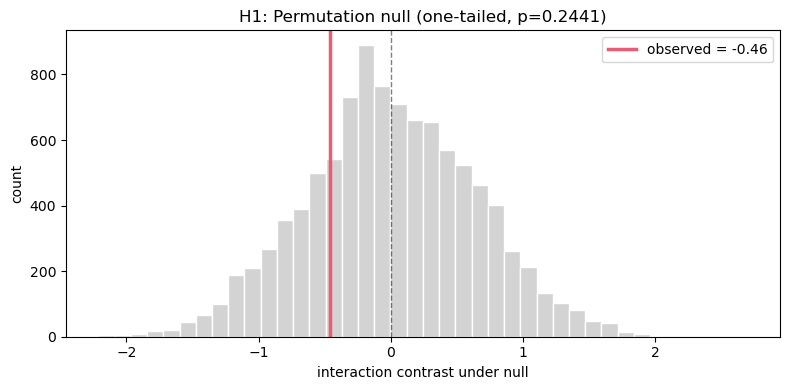

In [18]:
# [h1-plot]
# Plot the permutation null distribution with observed contrast
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_contrasts, bins=40, color="lightgray", edgecolor="white")
ax.axvline(observed_contrast, color="#E85D75", linewidth=2.5, label=f"observed = {observed_contrast:+.2f}")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("interaction contrast under null")
ax.set_ylabel("count")
ax.set_title(f"H1: Permutation null (one-tailed, p={p_perm:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## Interaction effect reframed: relative benefit of an obvious switch

The accuracy-based H1 contrast above is framed as the *extra penalty* of having a schema
when the R4 change is ambiguously vs. obviously incompatible. The same diff-in-diff can be
reframed as the *relative benefit* to Schema groups of an **Obviously Incompatible**
switch over an **Ambiguously Incompatible** one — using the Non-Schema group to control for the
baseline difficulty of the R4 task itself:

- `benefit(Schema) = mean(Schema, Obviously Incompatible) - mean(Schema, Ambiguously Incompatible)`
- `benefit(Non-Schema) = mean(Non-Schema, Obviously Incompatible) - mean(Non-Schema, Ambiguously Incompatible)`
- `relative_benefit = benefit(Schema) - benefit(Non-Schema)`

Algebraically `relative_benefit = -(H1 contrast)`, so the null distribution and
one-tailed p-value carry over. Predicted direction: **positive** (Schema groups
benefit more when the switch is obviously incompatible, because the schema isn't
seductively misleading them).

benefit(Schema):     mean(Schema,inc) - mean(Schema,amb)        = -0.652
benefit(Non-Schema): mean(NS,inc)     - mean(NS,amb)            = -1.114
relative_benefit   = benefit(Schema) - benefit(Non-Schema)      = +0.462
  (positive = Schema groups benefit more from the Obviously Incompatible switch, supports H1)

Restricted permutation test (one-tailed, relative_benefit > 0):
  observed = +0.462
  p (perm, n=10,000) = 0.2441
  (equals H1 p-value: 0.2441)


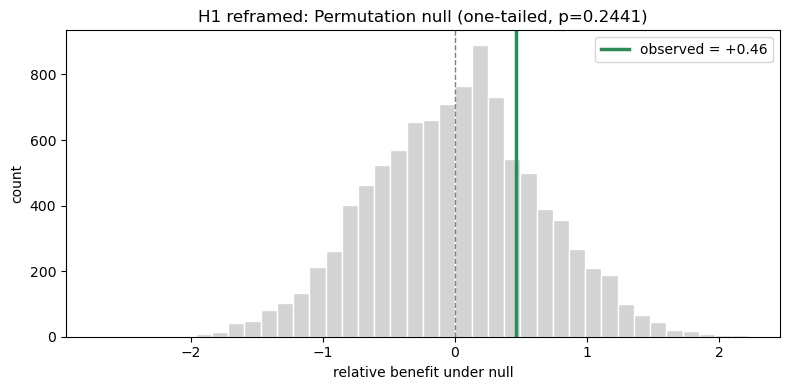

In [19]:
# [h1-reframed-relative-benefit]
benefit_schema = schema_inc.mean() - schema_amb.mean()
benefit_nonschema = nonschema_inc.mean() - nonschema_amb.mean()
relative_benefit_obs = benefit_schema - benefit_nonschema

# Reuse the restricted permutation null from H1 above (sign-flipped)
relative_benefit_null = -perm_contrasts
p_relative_benefit = (relative_benefit_null >= relative_benefit_obs).mean()  # one-tailed: more positive

# Sanity: should equal H1 p-value
assert abs(p_relative_benefit - p_perm) < 1e-9 or abs(relative_benefit_obs + observed_contrast) < 1e-9, \
    "relative benefit should be -contrast"

print(f"benefit(Schema):     mean(Schema,inc) - mean(Schema,amb)        = {benefit_schema:+.3f}")
print(f"benefit(Non-Schema): mean(NS,inc)     - mean(NS,amb)            = {benefit_nonschema:+.3f}")
print(f"relative_benefit   = benefit(Schema) - benefit(Non-Schema)      = {relative_benefit_obs:+.3f}")
print(f"  (positive = Schema groups benefit more from the Obviously Incompatible switch, supports H1)")
print(f"\nRestricted permutation test (one-tailed, relative_benefit > 0):")
print(f"  observed = {relative_benefit_obs:+.3f}")
print(f"  p (perm, n=10,000) = {p_relative_benefit:.4f}")
print(f"  (equals H1 p-value: {p_perm:.4f})")

# Plot null distribution under the new framing
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(relative_benefit_null, bins=40, color="lightgray", edgecolor="white")
ax.axvline(relative_benefit_obs, color="#2E8B57", linewidth=2.5, label=f"observed = {relative_benefit_obs:+.2f}")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("relative benefit under null")
ax.set_ylabel("count")
ax.set_title(f"H1 reframed: Permutation null (one-tailed, p={p_relative_benefit:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## Schema vs Non-Schema in the Obviously Incompatible (tangrams) arm

Direct comparison of round-4 accuracy between the two Obviously Incompatible arms (`schema_tangrams` and `nonschema_tangrams`). Tests whether the prior Schema vs Non-Schema effect persists when the R4 stimulus is the tangrams set rather than the lego-figure set.


In [20]:
# [r4-tangrams-schema-vs-nonschema]
# Direct Schema vs Non-Schema comparison within the Obviously Incompatible (tangrams) R4 arm.
# Uses the SAME nonparametric framework as Study 1's R4 accuracy test (and the
# replication check below): one-tailed permutation Mann-Whitney U (Schema < Non-Schema),
# with medians, the Hodges-Lehmann estimate (95% bootstrap CI), and Cliff's delta.
# A Welch t-test is intentionally NOT used here: R4 accuracy is a bounded 0-8 count,
# not normally distributed -- the same reason Study 1 used MWU rather than a t-test.
np.random.seed(42)

st = data.loc[data['treatment'] == 'schema_tangrams',    'accuracy_4'].values
nt = data.loc[data['treatment'] == 'nonschema_tangrams', 'accuracy_4'].values

# One-tailed permutation Mann-Whitney U: Schema < Non-Schema (direction from Study 1)
u_tang, p_perm_tang = perm_mwu_p(st, nt, alt="less")
_, p_asymp_tang = stats.mannwhitneyu(st, nt, alternative="less")

# Hodges-Lehmann estimate (schema - nonschema) + 95% bootstrap CI
hl_tang = np.median(st[:, np.newaxis] - nt)
n_boot = 9999
boot_hl = np.empty(n_boot)
rng_b = np.random.default_rng(42)
for i in range(n_boot):
    bs = rng_b.choice(st, size=len(st), replace=True)
    bn = rng_b.choice(nt, size=len(nt), replace=True)
    boot_hl[i] = np.median(bs[:, np.newaxis] - bn)
hl_ci_tang = np.percentile(boot_hl, [2.5, 97.5])

cd_tang = cliffs_delta(st, nt)

print("=" * 64)
print("R4 Obviously Incompatible (tangrams) arm: Schema vs Non-Schema accuracy")
print("=" * 64)
print(f"  Schema:     n={len(st):3d}  median={np.median(st):.1f}  mean={st.mean():.2f}")
print(f"  Non-schema: n={len(nt):3d}  median={np.median(nt):.1f}  mean={nt.mean():.2f}")
print(f"  Mann-Whitney U: U={u_tang:.1f}  p (asymp, one-tailed) = {p_asymp_tang:.4f}")
print(f"                  p (perm, one-tailed)  = {p_perm_tang:.4f}")
print(f"  Hodges-Lehmann (schema - nonschema): {hl_tang:+.2f}  [95% CI: {hl_ci_tang[0]:+.2f}, {hl_ci_tang[1]:+.2f}]")
print(f"  Cliff's delta: {cd_tang:+.3f}")


R4 Obviously Incompatible (tangrams) arm: Schema vs Non-Schema accuracy
  Schema:     n= 34  median=5.5  mean=5.18
  Non-schema: n= 35  median=7.0  mean=6.11
  Mann-Whitney U: U=463.0  p (asymp, one-tailed) = 0.0543
                  p (perm, one-tailed)  = 0.0543
  Hodges-Lehmann (schema - nonschema): -1.00  [95% CI: -2.00, +0.00]
  Cliff's delta: -0.222


## R4 accuracy by schema use × condition

Eight-cell descriptive subgroup analysis: round-4 accuracy split by whether the *dyad actually used a schema in R4* (per the human-annotated label coding), crossed with the 2 × 2 condition factors.

This isolates *behavioral* schema-use from *assigned* treatment: whether dyads in the Non-Schema condition who nonetheless used a schema in R4 perform differently from those who did not, and similarly for the Schema condition.


In [21]:
# [r4-accuracy-by-schema-use]
# Subgroup analysis: round-4 accuracy by (treatmentGroup, changeType, schema_use_4).
# Eight cells = 2 (Schema/Non-Schema) x 2 (lego/tangrams) x 2 (used schema in R4 / didn't).

import os

coding_path = "../data/study_2/schema_use_coding.csv"
if not os.path.exists(coding_path):
    print(f"[STUB] No schema-use coding at {coding_path}. Run [schema-use-coding-aggregation] first.")
else:
    coding = pd.read_csv(coding_path)
    subset = data[data['treatment'].isin(['schema','nonschema','schema_tangrams','nonschema_tangrams'])].copy()
    sub = subset.merge(coding[['gameId','schema_use_4']], on='gameId', how='left')
    sub['treatmentGroup'] = sub['treatmentGroup'].map(GROUP_LABELS)
    sub['changeType'] = sub['changeType'].map(CHANGE_LABELS)

    n_missing = sub['schema_use_4'].isna().sum()
    if n_missing:
        print(f"WARNING: {n_missing} groups missing schema-use coding — excluded from cells (shown separately below).")
        missing_df = sub[sub['schema_use_4'].isna()]
        print("\nMissing-coding groups by condition:")
        print(missing_df.groupby(['treatmentGroup','changeType']).size().unstack(fill_value=0))
        sub = sub.dropna(subset=['schema_use_4'])

    sub['schema_use_4'] = sub['schema_use_4'].astype(int)
    sub['used_schema'] = sub['schema_use_4'].map({1: 'used schema', 0: 'did not'})

    # 8-cell table: n, mean, sd, median
    stats_table = (sub.groupby(['treatmentGroup','changeType','used_schema'])['accuracy_4']
                      .agg(n='count', mean='mean', sd=lambda x: x.std(ddof=1), median='median')
                      .round(3)
                      .reset_index())

    print("R4 accuracy by condition × schema use (8 cells):")
    print("="*78)
    print(stats_table.to_string(index=False))

    # Pivoted view: rows = (treatmentGroup, changeType), cols = used_schema, value = mean (n)
    pivot_mean = sub.groupby(['treatmentGroup','changeType','used_schema'])['accuracy_4'].mean().unstack('used_schema').round(2)
    pivot_n    = sub.groupby(['treatmentGroup','changeType','used_schema'])['accuracy_4'].size().unstack('used_schema').fillna(0).astype(int)

    print("\nMean R4 accuracy (n) per cell:")
    print("-"*78)
    combined = pivot_mean.astype(str) + " (n=" + pivot_n.astype(str) + ")"
    print(combined.to_string())

    # Within each (treatmentGroup, changeType), how much do schema-users vs non-users differ?
    print("\nWithin-condition difference: (used schema) - (did not):")
    print("-"*78)
    for (tg, ct), g in sub.groupby(['treatmentGroup','changeType']):
        used = g.loc[g['schema_use_4']==1, 'accuracy_4']
        not_used = g.loc[g['schema_use_4']==0, 'accuracy_4']
        if len(used)==0 or len(not_used)==0:
            print(f"  {tg:<10s} × {ct:<24s}: insufficient data ({len(used)} used, {len(not_used)} did not)")
            continue
        diff = used.mean() - not_used.mean()
        print(f"  {tg:<10s} × {ct:<24s}: {diff:+.2f}   (used n={len(used)}, mean={used.mean():.2f}; did not n={len(not_used)}, mean={not_used.mean():.2f})")


R4 accuracy by condition × schema use (8 cells):
treatmentGroup               changeType used_schema  n  mean    sd  median
    Non-schema Ambiguously Incompatible     did not 33 7.182 1.158     8.0
    Non-schema Ambiguously Incompatible used schema  2 8.000 0.000     8.0
    Non-schema   Obviously Incompatible     did not 35 6.114 1.827     7.0
        Schema Ambiguously Incompatible     did not 13 6.000 2.646     8.0
        Schema Ambiguously Incompatible used schema 22 5.727 1.453     5.5
        Schema   Obviously Incompatible     did not 31 5.419 2.292     6.0
        Schema   Obviously Incompatible used schema  3 2.667 0.577     3.0

Mean R4 accuracy (n) per cell:
------------------------------------------------------------------------------
used_schema                                  did not  used schema
treatmentGroup changeType                                        
Non-schema     Ambiguously Incompatible  7.18 (n=33)    8.0 (n=2)
               Obviously Incompatible    6

## Replication check: Study 1 effects in the Schema × Ambiguously Incompatible arm

The Schema × Ambiguously Incompatible arm (treatment `schema` vs `nonschema`) uses identical lego-figure
stimuli and procedure to Study 1, so it should reproduce the Study 1 findings. The cell
below re-runs Study 1's full primary test battery on this arm — Round 3 and Round 4
**accuracy** and **labeling time** — using the same test for each metric as Study 1:
Welch's t-test for labeling time (continuous), and a permutation Mann–Whitney U with
Hodges–Lehmann estimate and Cliff's delta for the bounded 0–8 accuracy scale.
Directionality mirrors Study 1: R3 labeling time (schema faster) and R4 accuracy (schema
worse) are one-tailed; R3 accuracy and R4 labeling time are reported two-sided.

In [22]:
# [replication-check]
# Full replication of Study 1's statistical tests, applied to the Study 2
# schema-AMBIGUOUS arm (treatment "schema" vs "nonschema"): identical lego stimuli
# and procedure to Study 1. Self-contained (does not rely on helpers from other cells)
# so it mirrors Study 1's methods exactly:
#   * Labeling time (continuous, seconds): one-tailed Welch's t-test, mean difference
#     with Welch-Satterthwaite 95% CI, Cohen's d            (as in Study 1 H1).
#   * Accuracy (bounded 0-8 count): permutation Mann-Whitney U (9,999 perms, +1
#     correction), Hodges-Lehmann estimate with 95% bootstrap CI, Cliff's delta
#     (as in Study 1 H2b and its R3 companion).
# Directionality matches Study 1: labeling time is one-tailed in the predicted direction
# (R3 schema faster -- H1; R4 schema slower -- Study 1's exploratory R4 time test), and
# accuracy is one-tailed for R4 (schema less accurate -- H2b) but two-sided for R3 (no prediction).
np.random.seed(42)

amb_s  = data[data["treatment"] == "schema"]      # schema    x ambiguous (lego)
amb_ns = data[data["treatment"] == "nonschema"]   # nonschema x ambiguous (lego)
N_PERM, N_BOOT = 9999, 9999

def _welch(s, ns, alternative):
    s = np.asarray(s, float); ns = np.asarray(ns, float)
    t, pval = stats.ttest_ind(s, ns, equal_var=False, alternative=alternative)
    n1, n2 = len(s), len(ns); v1, v2 = s.var(ddof=1), ns.var(ddof=1)
    md = s.mean() - ns.mean(); se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    tcrit = stats.t.ppf(0.975, df)
    pooled = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
    return dict(t=t, p=pval, df=df, md=md, lo=md-tcrit*se, hi=md+tcrit*se, d=md/pooled,
                m1=s.mean(), sd1=s.std(ddof=1), m2=ns.mean(), sd2=ns.std(ddof=1), n1=n1, n2=n2)

def _perm_mwu(s, ns, alternative):
    s = np.asarray(s, float); ns = np.asarray(ns, float)
    u_obs = stats.mannwhitneyu(s, ns, alternative="two-sided").statistic
    pool = np.concatenate([s, ns]); k = len(s)
    rng = np.random.default_rng(42)
    perm_u = np.array([stats.mannwhitneyu(
        (perm := rng.permutation(pool))[:k], perm[k:], alternative="two-sided").statistic
        for _ in range(N_PERM)])
    p_less    = (np.sum(perm_u <= u_obs) + 1) / (N_PERM + 1)
    p_greater = (np.sum(perm_u >= u_obs) + 1) / (N_PERM + 1)
    p = p_less if alternative == "less" else p_greater if alternative == "greater" \
        else min(1.0, 2 * min(p_less, p_greater))
    hl = np.median(s[:, np.newaxis] - ns)
    rb = np.random.default_rng(42)
    boot = np.array([np.median(rb.choice(s, len(s))[:, None] - rb.choice(ns, len(ns)))
                     for _ in range(N_BOOT)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    n1, n2 = len(s), len(ns)
    delta = (np.sum(s[:, None] > ns) - np.sum(s[:, None] < ns)) / (n1 * n2)
    return dict(u=u_obs, p=p, hl=hl, lo=lo, hi=hi, delta=delta,
                m1=s.mean(), md1=np.median(s), m2=ns.mean(), md2=np.median(ns), n1=n1, n2=n2)

print("=" * 72)
print("Study 1 replication on the Study 2 schema-AMBIGUOUS arm (schema vs nonschema)")
print("=" * 72)

print("\n--- LABELING TIME (Welch's t-test, as Study 1 H1) ---")
for lbl, alt, col in [("R3 labeling time (s)  [1-tailed schema<NS, ~Study 1 H1]", "less",      "time_labeling_3"),
                      ("R4 labeling time (s)  [1-tailed schema>NS, ~Study 1 R4 time]", "greater", "time_labeling_4")]:
    r = _welch(amb_s[col], amb_ns[col], alt)
    print(f"\n{lbl}")
    print(f"  schema    n={r['n1']:3d}  mean={r['m1']:7.2f} (sd {r['sd1']:6.2f})")
    print(f"  nonschema n={r['n2']:3d}  mean={r['m2']:7.2f} (sd {r['sd2']:6.2f})")
    print(f"  diff (schema - nonschema) = {r['md']:+7.2f}  [95% CI {r['lo']:+.2f}, {r['hi']:+.2f}]")
    print(f"  Welch t({r['df']:.1f}) = {r['t']:.3f},  p = {r['p']:.4f},  Cohen's d = {r['d']:+.3f}")

print("\n--- ACCURACY (permutation Mann-Whitney U + Hodges-Lehmann + Cliff's delta, as Study 1 H2b) ---")
acc = {}
for lbl, alt, col in [("R3 accuracy (0-8)  [2-tailed, ~Study 1 R3]", "two-sided", "accuracy_3"),
                      ("R4 accuracy (0-8)  [1-tailed schema<NS, ~Study 1 H2b]",  "less",      "accuracy_4")]:
    r = _perm_mwu(amb_s[col], amb_ns[col], alt); acc[col] = r
    print(f"\n{lbl}")
    print(f"  schema    n={r['n1']:3d}  median={r['md1']:.1f}  mean={r['m1']:.2f}")
    print(f"  nonschema n={r['n2']:3d}  median={r['md2']:.1f}  mean={r['m2']:.2f}")
    print(f"  Mann-Whitney U = {r['u']:.1f},  perm p = {r['p']:.4f}")
    print(f"  Hodges-Lehmann (schema - nonschema) = {r['hl']:+.2f}  [95% boot CI {r['lo']:+.2f}, {r['hi']:+.2f}]")
    print(f"  Cliff's delta = {r['delta']:+.3f}")

# variables consumed by the summary table (R4 accuracy = headline replication target)
u_rep_obs, p_rep_perm, hl_rep, cd_rep = (acc["accuracy_4"]["u"], acc["accuracy_4"]["p"],
                                         acc["accuracy_4"]["hl"], acc["accuracy_4"]["delta"])


Study 1 replication on the Study 2 schema-AMBIGUOUS arm (schema vs nonschema)

--- LABELING TIME (Welch's t-test, as Study 1 H1) ---

R3 labeling time (s)  [1-tailed schema<NS, ~Study 1 H1]
  schema    n= 35  mean= 128.91 (sd  52.86)
  nonschema n= 35  mean= 180.66 (sd  60.87)
  diff (schema - nonschema) =  -51.75  [95% CI -78.95, -24.54]
  Welch t(66.7) = -3.797,  p = 0.0002,  Cohen's d = -0.908

R4 labeling time (s)  [1-tailed schema>NS, ~Study 1 R4 time]
  schema    n= 35  mean= 232.13 (sd  68.97)
  nonschema n= 35  mean= 175.75 (sd  70.70)
  diff (schema - nonschema) =  +56.38  [95% CI +23.06, +89.69]
  Welch t(68.0) = 3.377,  p = 0.0006,  Cohen's d = +0.807

--- ACCURACY (permutation Mann-Whitney U + Hodges-Lehmann + Cliff's delta, as Study 1 H2b) ---

R3 accuracy (0-8)  [2-tailed, ~Study 1 R3]
  schema    n= 35  median=8.0  mean=7.20
  nonschema n= 35  median=8.0  mean=7.37
  Mann-Whitney U = 537.0,  perm p = 0.3060
  Hodges-Lehmann (schema - nonschema) = +0.00  [95% boot CI +0.0

Saved figures/study2_round4_outcomes.* (4.49 x 3.45 in; R4-only ambiguously- vs obviously-incompatible contrast)


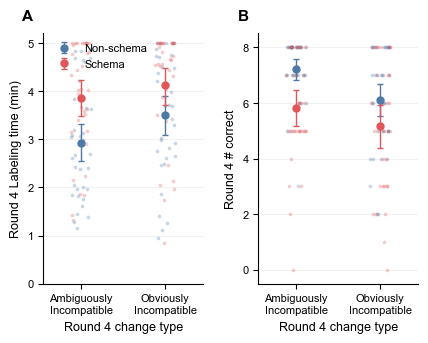

In [23]:
# [fig-r4-contrast]
# Round-4 only, focusing on the ambiguously- vs obviously-incompatible change contrast. 1x2: labeling time
# (left) and accuracy (right). Within each panel, x = Round-4 change type (Ambiguously Incompatible /
# Obviously Incompatible); Schema and Non-schema share each x (parallels Study 1), color-coded, with NO
# connecting line (the change types are categorical, not a chronological progression). Same style as [fig-r3-r4-pnas]:
# jittered dots, mean circle, 95% bootstrap CI; PNAS 1.5-column; fonts match Study 1.
import os

pnas_style = {'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':8,'axes.labelsize':9,'axes.titlesize':9,'xtick.labelsize':8,'ytick.labelsize':8,
    'legend.fontsize':8,'axes.linewidth':0.8,'xtick.major.width':0.8,'ytick.major.width':0.8,
    'lines.linewidth':1.5,'lines.markersize':5,'patch.linewidth':0.6}
colors = {'nonschema':'#4E79A7','schema':'#E15759'}
labels = {'nonschema':'Non-schema','schema':'Schema'}

def _boot_ci(x, n_boot=10000, seed=42):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    rng = np.random.default_rng(seed)
    bm = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(bm, [2.5, 97.5]); return x.mean(), lo, hi

FIGW_TARGET = 4.49; AH = 2.502                 # PNAS 1.5-col; panel height matches Study 1
L, R, GX, B, T = 0.62, 0.12, 0.55, 0.55, 0.40
AW = (FIGW_TARGET - L - R - GX) / 2; FIGW = FIGW_TARGET; FIGH = T + AH + B
XLIM = (-0.45, 1.45); YLABX = -0.13
metrics = [('time', lambda v: v/60.0, 'Round 4 Labeling time (min)', 'time_labeling_4'),
           ('acc',  lambda v: v,       'Round 4 # correct',           'accuracy_4')]
ct_order = ['ambiguous', 'incompatible']; ct_tick = ['Ambiguously\nIncompatible', 'Obviously\nIncompatible']
letters = ['A', 'B']

with plt.rc_context(pnas_style):
    fig = plt.figure(figsize=(FIGW, FIGH)); np.random.seed(42)
    for c, (mkey, tf, ylabel, col) in enumerate(metrics):
        x0 = (L if c == 0 else L + AW + GX)/FIGW
        ax = fig.add_axes([x0, B/FIGH, AW/FIGW, AH/FIGH])
        for cond in ['nonschema', 'schema']:
            xs, ms, los, his = [], [], [], []
            for ci, ct in enumerate(ct_order):
                sub = data[(data['treatmentGroup']==cond) & (data['changeType']==ct)]
                xpos = ci
                vals = tf(sub[col].dropna().values); jit = np.random.uniform(-0.12, 0.12, len(vals))
                ax.scatter(xpos + jit, vals, color=colors[cond], alpha=0.3, s=7, zorder=2, linewidths=0)
                m, lo, hi = _boot_ci(tf(sub[col].values)); xs.append(xpos); ms.append(m); los.append(lo); his.append(hi)
            yerr = np.array([[m-lo for m, lo in zip(ms, los)], [hi-m for m, hi in zip(ms, his)]])
            # same x for both conditions (parallels Study 1); no connecting line (not chronological)
            ax.errorbar(xs, ms, yerr=yerr, fmt='o', linestyle='none', color=colors[cond], markersize=5,
                        label=labels[cond], zorder=4, elinewidth=1, capsize=2, capthick=1)
        ax.set_xticks([0,1]); ax.set_xticklabels(ct_tick); ax.set_xlim(*XLIM)
        ax.set_xlabel('Round 4 change type')
        ax.set_ylabel(ylabel); ax.yaxis.set_label_coords(YLABX, 0.5)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if mkey == 'acc': ax.set_ylim(-0.5, 8.5); ax.set_yticks(range(0, 9, 2))
        else: ax.set_ylim(0, 5.2); ax.set_yticks(range(0, 6))
        ax.text(YLABX, 1.04, letters[c], transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='bottom', ha='left')
    fig.axes[0].legend(frameon=False, loc='upper left')
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/study2_round4_outcomes.pdf', bbox_inches='tight')
    plt.savefig('figures/study2_round4_outcomes.png', dpi=300, bbox_inches='tight')
    print(f"Saved figures/study2_round4_outcomes.* ({FIGW:.2f} x {FIGH:.2f} in; R4-only ambiguously- vs obviously-incompatible contrast)")
    plt.show()


In [24]:
# [r4-gap-by-changetype]
# Schema vs Non-schema R4 performance gap, computed SEPARATELY for the ambiguously-incompatible (lego)
# and obviously-incompatible (tangrams) change, using Study 1's exact statistics. Self-contained.
#   * Accuracy (0-8 count): one-tailed permutation Mann-Whitney U (schema < nonschema),
#     Hodges-Lehmann shift (95% bootstrap CI), Cliff's delta            (as Study 1 H2b)
#   * Labeling time (s): one-tailed Welch's t (schema > nonschema -- schema slower once the
#     schema is broken), two-tailed also reported; mean diff (Welch-Satterthwaite 95% CI),
#     Cohen's d                                                  (as Study 1's R4 time test)
# Prediction: the Study 1 R4 deficit replicates under the ambiguously-incompatible change (groups can't
# tell the schema no longer applies) but attenuates under the obviously-incompatible change (the tangrams
# make the incompatibility unmistakable). NB the obviously-incompatible-arm accuracy gap is also confounded
# by a ceiling effect in the non-schema control (54% of non-schema groups were at the 8/8
# ceiling in the ambiguously-incompatible arm), so read the obvious-arm accuracy comparison with care.
np.random.seed(42)
N_PERM, N_BOOT = 9999, 9999

def _welch(s, ns, alternative):
    s = np.asarray(s, float); ns = np.asarray(ns, float)
    t, pval = stats.ttest_ind(s, ns, equal_var=False, alternative=alternative)
    n1, n2 = len(s), len(ns); v1, v2 = s.var(ddof=1), ns.var(ddof=1)
    md = s.mean() - ns.mean(); se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    tcrit = stats.t.ppf(0.975, df); pooled = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
    return dict(t=t, p=pval, df=df, md=md, lo=md-tcrit*se, hi=md+tcrit*se, d=md/pooled,
                m1=s.mean(), sd1=s.std(ddof=1), m2=ns.mean(), sd2=ns.std(ddof=1), n1=n1, n2=n2)

def _perm_mwu(s, ns, alternative):
    s = np.asarray(s, float); ns = np.asarray(ns, float)
    u_obs = stats.mannwhitneyu(s, ns, alternative="two-sided").statistic
    pool = np.concatenate([s, ns]); k = len(s); rng = np.random.default_rng(42)
    perm_u = np.array([stats.mannwhitneyu(
        (perm := rng.permutation(pool))[:k], perm[k:], alternative="two-sided").statistic
        for _ in range(N_PERM)])
    p_less    = (np.sum(perm_u <= u_obs) + 1) / (N_PERM + 1)
    p_greater = (np.sum(perm_u >= u_obs) + 1) / (N_PERM + 1)
    p = p_less if alternative == "less" else p_greater if alternative == "greater" \
        else min(1.0, 2 * min(p_less, p_greater))
    hl = np.median(s[:, np.newaxis] - ns)
    rb = np.random.default_rng(42)
    boot = np.array([np.median(rb.choice(s, len(s))[:, None] - rb.choice(ns, len(ns)))
                     for _ in range(N_BOOT)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    n1, n2 = len(s), len(ns)
    delta = (np.sum(s[:, None] > ns) - np.sum(s[:, None] < ns)) / (n1 * n2)
    return dict(u=u_obs, p=p, hl=hl, lo=lo, hi=hi, delta=delta,
                m1=s.mean(), md1=np.median(s), m2=ns.mean(), md2=np.median(ns), n1=n1, n2=n2)

for ct, name in [("ambiguous",   "Ambiguously Incompatible (lego)"),
                 ("incompatible","Obviously Incompatible (tangrams)")]:
    s  = data[(data["treatmentGroup"] == "schema")    & (data["changeType"] == ct)]
    ns = data[(data["treatmentGroup"] == "nonschema") & (data["changeType"] == ct)]
    print("=" * 74); print(f"R4 schema vs non-schema  --  {name}"); print("=" * 74)
    r = _perm_mwu(s["accuracy_4"], ns["accuracy_4"], "less")
    print(f"  ACCURACY (0-8)   schema n={r['n1']:2d} median={r['md1']:.1f} mean={r['m1']:.2f}  |  "
          f"non-schema n={r['n2']:2d} median={r['md2']:.1f} mean={r['m2']:.2f}")
    print(f"     perm MWU (1-tailed, schema<NS) U={r['u']:.0f}, p={r['p']:.4f}   "
          f"Hodges-Lehmann={r['hl']:+.1f} [95% CI {r['lo']:+.1f}, {r['hi']:+.1f}]   Cliff's δ={r['delta']:+.3f}")
    w = _welch(s["time_labeling_4"], ns["time_labeling_4"], "greater")  # schema slower (as Study 1 R4)
    p_two = stats.ttest_ind(s["time_labeling_4"], ns["time_labeling_4"], equal_var=False, alternative="two-sided")[1]
    print(f"  LABELING TIME(s) schema mean={w['m1']:.1f} (sd {w['sd1']:.0f})  |  "
          f"non-schema mean={w['m2']:.1f} (sd {w['sd2']:.0f})")
    print(f"     Welch t({w['df']:.0f})={w['t']:.2f}   p(1-tailed schema>NS)={w['p']:.4f}   p(2-tailed)={p_two:.4f}")
    print(f"     diff={w['md']:+.0f}s [95% CI {w['lo']:+.0f}, {w['hi']:+.0f}]   Cohen's d={w['d']:+.2f}")
    print()
print("Summary: the R4 RECALL deficit (Study 1 H2b) replicates under the ambiguously-incompatible change")
print("and is no longer significant under the obviously-incompatible change; the labeling-time gap (schema")
print("slower) holds in both arms but attenuates. NB the obviously-incompatible-arm accuracy gap is partly")
print("confounded by a ceiling effect in the non-schema control (see distribution check).")


R4 schema vs non-schema  --  Ambiguously Incompatible (lego)
  ACCURACY (0-8)   schema n=35 median=6.0 mean=5.83  |  non-schema n=35 median=8.0 mean=7.23
     perm MWU (1-tailed, schema<NS) U=343, p=0.0008   Hodges-Lehmann=-1.0 [95% CI -2.0, +0.0]   Cliff's δ=-0.440
  LABELING TIME(s) schema mean=232.1 (sd 69)  |  non-schema mean=175.8 (sd 71)
     Welch t(68)=3.38   p(1-tailed schema>NS)=0.0006   p(2-tailed)=0.0012
     diff=+56s [95% CI +23, +90]   Cohen's d=+0.81

R4 schema vs non-schema  --  Obviously Incompatible (tangrams)
  ACCURACY (0-8)   schema n=34 median=5.5 mean=5.18  |  non-schema n=35 median=7.0 mean=6.11
     perm MWU (1-tailed, schema<NS) U=463, p=0.0544   Hodges-Lehmann=-1.0 [95% CI -2.0, +0.0]   Cliff's δ=-0.222
  LABELING TIME(s) schema mean=247.5 (sd 70)  |  non-schema mean=209.8 (sd 74)
     Welch t(67)=2.17   p(1-tailed schema>NS)=0.0166   p(2-tailed)=0.0333
     diff=+38s [95% CI +3, +72]   Cohen's d=+0.52

Summary: the R4 RECALL deficit (Study 1 H2b) replicates

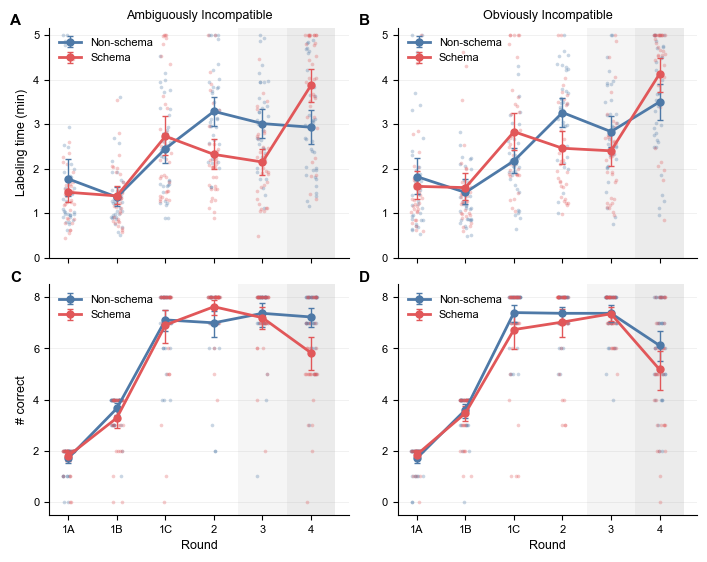

Fig. S1. Labeling time (A, B) and accuracy (C, D) across all rounds, by Round-4 change type. Lines show condition means with 95% bootstrap-CI error bars; points show individual groups (jittered horizontally). Shaded regions mark the Round-3 and Round-4 test rounds. Training rounds 1A and 1B contained 2 and 4 images; all other rounds 8.


In [25]:
# [fig-all-rounds]
# SI figure (figureS1): labeling time + accuracy across all rounds, faceted by R4
# change type. Styled to match Study 1's Figure 1 -- pnas_style rc, Tableau palette,
# minute-scaled time axis, '# correct' accuracy axis, shaded R3/R4 test rounds, and
# 95% bootstrap-CI error bars over jittered group points.
import os

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'lines.linewidth': 1.5, 'lines.markersize': 5, 'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red (= Study 1)
labels = {'nonschema': 'Non-schema', 'schema': 'Schema'}
ct_label = {'ambiguous': 'Ambiguously Incompatible', 'incompatible': 'Obviously Incompatible'}

time_round_cols = ['time_labeling_1a', 'time_labeling_1b', 'time_labeling_1c',
                   'time_labeling_2', 'time_labeling_3', 'time_labeling_4']
acc_round_cols  = ['accuracy_1a', 'accuracy_1b', 'accuracy_1c',
                   'accuracy_2', 'accuracy_3', 'accuracy_4']
round_lbls = ['1A', '1B', '1C', '2', '3', '4']
letters = [['A', 'B'], ['C', 'D']]
np.random.seed(42)

with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.6), sharex=True)
    panels = [
        (0, time_round_cols, 'Labeling time (min)', (0, 310), True),
        (1, acc_round_cols,  '# correct',           (-0.5, 8.5), False),
    ]
    for row, cols, ylabel, ylim, is_time in panels:
        for col_idx, ct in enumerate(['ambiguous', 'incompatible']):
            ax = axes[row, col_idx]
            # shade the preregistered test rounds (R3, R4), as in Study 1
            ax.axvspan(3.5, 4.5, color='#f5f5f5', zorder=0, linewidth=0)
            ax.axvspan(4.5, 5.5, color='#ebebeb', zorder=0, linewidth=0)
            x = np.arange(len(cols))
            for tg in ['nonschema', 'schema']:
                sub = data[(data['treatmentGroup'] == tg) & (data['changeType'] == ct)]
                if len(sub) == 0:
                    continue
                means = [sub[c].mean() for c in cols]
                ci = [_boot_ci(sub[c].values) for c in cols]
                yerr = np.array([[m - lo for (m, lo, hi) in ci],
                                 [hi - m for (m, lo, hi) in ci]])
                for xi, col in enumerate(cols):
                    vals = sub[col].dropna().values
                    jit = np.random.uniform(-0.12, 0.12, len(vals))
                    ax.scatter(xi + jit, vals, color=colors[tg],
                               alpha=0.3, s=7, zorder=2, linewidths=0)
                ax.errorbar(x, means, yerr=yerr, marker='o', linewidth=2,
                            color=colors[tg], markersize=5, label=labels[tg],
                            zorder=4, elinewidth=1, capsize=2, capthick=1)
            ax.set_xticks(x)
            ax.set_xticklabels(round_lbls)
            ax.set_ylim(*ylim)
            ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if row == 1:
                ax.set_xlabel('Round')
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            if row == 0:
                ax.set_title(ct_label[ct])
            if is_time:
                ax.set_yticks(range(0, 310, 60))
                ax.set_yticklabels(range(0, 6, 1))
            else:
                ax.set_yticks(range(0, 9, 2))
            ax.legend(frameon=False, loc='upper left')
            ax.text(-0.13, 1.06, letters[row][col_idx], transform=ax.transAxes,
                    fontsize=11, fontweight='bold', va='top')
    plt.tight_layout(pad=0.8, w_pad=1.5)
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/figureS1.pdf', bbox_inches='tight')
    plt.savefig('figures/figureS1.png', dpi=300, bbox_inches='tight')
    plt.show()

print("Fig. S1. Labeling time (A, B) and accuracy (C, D) across all rounds, by Round-4 "
      "change type. Lines show condition means with 95% bootstrap-CI error bars; points show "
      "individual groups (jittered horizontally). Shaded regions mark the Round-3 and Round-4 "
      "test rounds. Training rounds 1A and 1B contained 2 and 4 images; all other rounds 8.")

## Exploratory: self-reported recall confidence

After each labeling phase, every participant rated **"How confident are you that
you'll remember the names you chose?"** on a 5-point scale (*not at all* →
*extremely* confident). This item was collected in every round but was **not part
of the preregistered analyses**; everything below is exploratory and descriptive.

The measure is interesting through a competency-trap lens. Confidence is reported
*before* the recall test, so it is a forward-looking self-assessment of one's own
strategy. Round 4 is where the image environment changes, so it is the round where
a strategy that worked before may quietly stop working. If confidence stays high
into R4 while accuracy collapses — especially for Schema groups facing the
*Ambiguously Incompatible* change — that miscalibration is the behavioral signature
of a competency trap: continued faith in a strategy after it has stopped paying off.

In [26]:
# [conf-parse]
# Parse the per-round confidence ratings into the analyzed participant-level frame.
# Ordinal coding: 1 = "Not at all confident" ... 5 = "Extremely confident".
CONF_LEVELS = {
    "Not at all confident": 1,
    "Slightly confident": 2,
    "Moderately confident": 3,
    "Very confident": 4,
    "Extremely confident": 5,
}
conf_rounds = ["1a", "1b", "1c", "2", "3", "4"]

def get_confidence(row):
    out = {}
    for r in conf_rounds:
        try:
            out[f"conf_{r}"] = CONF_LEVELS[row["prompts"][f"prompt_confidence_{r}"]["value"]]
        except (KeyError, TypeError):
            out[f"conf_{r}"] = np.nan
    return out

# `raw` is the unfiltered load; key by sampleId and map onto the analyzed sample.
conf_by_sample = {row["sampleId"]: get_confidence(row) for row in raw if row["sampleId"] != "missing"}
conf_cols = [f"conf_{r}" for r in conf_rounds]
for c in conf_cols:
    all_data[c] = all_data["sampleId"].map(lambda s, c=c: conf_by_sample.get(s, {}).get(c, np.nan))

print(f"Confidence coverage in the analyzed sample (n={len(all_data)} participants):")
coverage = all_data[conf_cols].notna().sum().rename("n_responses")
coverage.index = [c.replace("conf_", "R") for c in coverage.index]
print(coverage.to_frame().T.to_string(index=False))
print("\nMean confidence by round (1=not at all ... 5=extremely confident):")
print(all_data[conf_cols].mean().round(2).rename(lambda c: c.replace("conf_", "R")).to_string())

Confidence coverage in the analyzed sample (n=278 participants):
 R1a  R1b  R1c  R2  R3  R4
 277  277  277 278 276 278

Mean confidence by round (1=not at all ... 5=extremely confident):
R1a    4.63
R1b    4.64
R1c    4.32
R2     4.16
R3     4.20
R4     3.55


In [27]:
# [conf-long]
# Tidy long form: one row per participant x round, pairing the participant's
# confidence with their group's recall accuracy for that round (accuracy is a
# group-level outcome -- a round scores only when the whole group matches).
id_cols = ["gameId", "sampleId", "position", "treatment", "treatmentGroup", "changeType"]
conf_long = all_data.melt(id_vars=id_cols, value_vars=conf_cols,
                          var_name="round", value_name="confidence")
conf_long["round"] = conf_long["round"].str.replace("conf_", "", regex=False)
acc_long = all_data.melt(id_vars=["sampleId"],
                         value_vars=[f"accuracy_{r}" for r in conf_rounds],
                         var_name="round", value_name="accuracy")
acc_long["round"] = acc_long["round"].str.replace("accuracy_", "", regex=False)
conf_long = conf_long.merge(acc_long, on=["sampleId", "round"]).dropna(subset=["confidence"])

# Mean confidence by design cell, restricted to the scored rounds (2, 3, 4).
scored = conf_long[conf_long["round"].isin(["2", "3", "4"])]
print("Mean confidence by design cell and round (scored rounds):")
print(scored.pivot_table(index=["treatmentGroup", "changeType"],
                         columns="round", values="confidence", aggfunc="mean").round(2))

Mean confidence by design cell and round (scored rounds):
round                           2     3     4
treatmentGroup changeType                    
nonschema      ambiguous     3.93  3.84  3.99
               incompatible  3.86  3.93  3.31
schema         ambiguous     4.54  4.49  3.73
               incompatible  4.31  4.56  3.16


In [28]:
# [conf-calibration]
# Calibration: does higher self-reported confidence track higher recall accuracy?
# Confidence is individual while accuracy is a group outcome, so we expect an
# attenuated (not perfect) positive association. Spearman is used because the
# confidence scale is ordinal.
print("Spearman rho between individual confidence and group accuracy:")
for r in ["2", "3", "4"]:
    sub = conf_long[conf_long["round"] == r]
    rho, p = stats.spearmanr(sub["confidence"], sub["accuracy"])
    print(f"  R{r}:        rho={rho:+.3f}   p={p:.3f}   n={len(sub)}")
pooled = conf_long[conf_long["round"].isin(["2", "3", "4"])]
rho, p = stats.spearmanr(pooled["confidence"], pooled["accuracy"])
print(f"  R2-R4 pool: rho={rho:+.3f}   p={p:.3f}   n={len(pooled)}")

Spearman rho between individual confidence and group accuracy:
  R2:        rho=+0.301   p=0.000   n=278
  R3:        rho=+0.084   p=0.166   n=276
  R4:        rho=+0.183   p=0.002   n=278
  R2-R4 pool: rho=+0.259   p=0.000   n=832


In [29]:
# [conf-r4-overconfidence]
# Competency-trap lens: compare the R3->R4 change in confidence (individual)
# against the R3->R4 change in accuracy (group), per design cell. A flat/positive
# confidence change paired with a steep accuracy drop is the overconfidence
# (miscalibration) signature -- expected to be sharpest for schema / ambiguous.
delta = all_data.copy()
delta["d_conf"] = delta["conf_4"] - delta["conf_3"]
delta["d_acc"] = delta["accuracy_4"] - delta["accuracy_3"]
overconf = (delta.groupby(["treatmentGroup", "changeType"])
            .agg(n=("sampleId", "count"),
                 conf_R3=("conf_3", "mean"), conf_R4=("conf_4", "mean"), d_conf=("d_conf", "mean"),
                 acc_R3=("accuracy_3", "mean"), acc_R4=("accuracy_4", "mean"), d_acc=("d_acc", "mean"))
            .round(2))
print(overconf)
print("\nd_conf near 0 (or positive) while d_acc is strongly negative")
print("indicates confidence that did not update to the R4 environment change.")

                              n  conf_R3  conf_R4  d_conf  acc_R3  acc_R4  \
treatmentGroup changeType                                                   
nonschema      ambiguous     70     3.84     3.99    0.14    7.37    7.23   
               incompatible  70     3.93     3.31   -0.61    7.37    6.11   
schema         ambiguous     70     4.49     3.73   -0.78    7.20    5.83   
               incompatible  68     4.56     3.16   -1.40    7.35    5.18   

                             d_acc  
treatmentGroup changeType           
nonschema      ambiguous     -0.14  
               incompatible  -1.26  
schema         ambiguous     -1.37  
               incompatible  -2.18  

d_conf near 0 (or positive) while d_acc is strongly negative
indicates confidence that did not update to the R4 environment change.


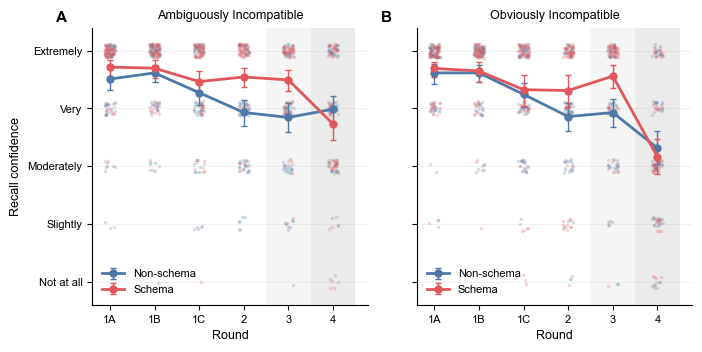

Fig. S2. Self-reported recall confidence across rounds, by Round-4 change type. After each labeling phase, participants rated how confident they were that they would remember their labels (5-point scale). Lines show condition means with 95% bootstrap-CI error bars; points show individual participants (jittered). Shaded regions mark the Round-3 and Round-4 test rounds. This measure was collected but not preregistered.


In [30]:
# [fig-conf-trajectory]
# SI figure (figureS2): mean self-reported recall confidence across rounds, faceted
# by R4 change type. EXPLORATORY -- confidence was collected but not preregistered.
# Styled to match figureS1 / Study 1's Figure 1 (pnas_style rc, Tableau palette, shaded
# R3/R4 test rounds, 95% bootstrap-CI error bars over jittered participant points).
# Confidence is individual; ordinal text responses are mapped to 1-5 only to compute the
# mean -- the y-axis shows the original labels, not numbers.
import os

pnas_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'lines.linewidth': 1.5, 'lines.markersize': 5, 'patch.linewidth': 0.6,
}
colors = {'nonschema': '#4E79A7', 'schema': '#E15759'}   # Tableau blue / red (= Study 1)
labels = {'nonschema': 'Non-schema', 'schema': 'Schema'}
ct_label = {'ambiguous': 'Ambiguously Incompatible', 'incompatible': 'Obviously Incompatible'}

conf_round_cols = [f'conf_{r}' for r in ['1a', '1b', '1c', '2', '3', '4']]
round_lbls = ['1A', '1B', '1C', '2', '3', '4']
conf_tick_labels = ['Not at all', 'Slightly', 'Moderately', 'Very', 'Extremely']
letters = ['A', 'B']
np.random.seed(42)

with plt.rc_context(pnas_style):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.5), sharey=True)
    for col_idx, ct in enumerate(['ambiguous', 'incompatible']):
        ax = axes[col_idx]
        # shade the preregistered test rounds (R3, R4), as in figureS1
        ax.axvspan(3.5, 4.5, color='#f5f5f5', zorder=0, linewidth=0)
        ax.axvspan(4.5, 5.5, color='#ebebeb', zorder=0, linewidth=0)
        x = np.arange(len(conf_round_cols))
        for tg in ['nonschema', 'schema']:
            sub = all_data[(all_data['treatmentGroup'] == tg) & (all_data['changeType'] == ct)]
            if len(sub) == 0:
                continue
            ci = [_boot_ci(sub[c]) for c in conf_round_cols]
            means = [m for m, lo, hi in ci]
            yerr = np.array([[m - lo for m, lo, hi in ci],
                             [hi - m for m, lo, hi in ci]])
            for xi, col in enumerate(conf_round_cols):
                vals = sub[col].dropna().values
                jx = np.random.uniform(-0.12, 0.12, len(vals))
                jy = np.random.uniform(-0.12, 0.12, len(vals))
                ax.scatter(xi + jx, vals + jy, color=colors[tg],
                           alpha=0.25, s=6, zorder=2, linewidths=0)
            ax.errorbar(x, means, yerr=yerr, marker='o', linewidth=2,
                        color=colors[tg], markersize=5, label=labels[tg],
                        zorder=4, elinewidth=1, capsize=2, capthick=1)
        ax.set_xticks(x)
        ax.set_xticklabels(round_lbls)
        ax.set_xlabel('Round')
        ax.set_title(ct_label[ct])
        ax.set_ylim(0.6, 5.4)
        ax.set_yticks([1, 2, 3, 4, 5])
        if col_idx == 0:
            ax.set_yticklabels(conf_tick_labels)
            ax.set_ylabel('Recall confidence')
        ax.grid(axis='y', alpha=0.25, linewidth=0.5, linestyle='-')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, loc='lower left')
        ax.text(-0.13, 1.06, letters[col_idx], transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')
    plt.tight_layout(pad=0.8, w_pad=1.5)
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/figureS2.pdf', bbox_inches='tight')
    plt.savefig('figures/figureS2.png', dpi=300, bbox_inches='tight')
    plt.show()

print("Fig. S2. Self-reported recall confidence across rounds, by Round-4 change type. After each "
      "labeling phase, participants rated how confident they were that they would remember their "
      "labels (5-point scale). Lines show condition means with 95% bootstrap-CI error bars; points "
      "show individual participants (jittered). Shaded regions mark the Round-3 and Round-4 test "
      "rounds. This measure was collected but not preregistered.")

### Post-game surveys: discussion experience and open responses

Beyond confidence, each participant completed an end-of-game **Discussion (General)**
survey (`@watts-lab/surveys`) — 10 items on a 0–1 scale covering how much they
enjoyed the discussion, how much they felt they learned, its depth, disagreement and
tension, and psychological safety (feeling able to speak up, heard, anxious, judged).
They also answered three **open-text** reflection prompts about their labeling
*strategy*, their *mistakes*, and how the pair *worked together*.

These are exploratory and descriptive. The most natural contrast is Schema vs.
Non-schema: did imposing a schema change how the collaboration *felt*, and do
participants describe qualitatively different strategies and error modes?

In [31]:
# [survey-parse]
# Parse the end-of-game "Discussion (General)" survey into the analyzed sample.
# Ten items on a 0-1 scale (0, .25, .5, .75, 1). Also pull the three open-text
# reflection prompts for the qualitative review further down.
DISCUSSION_ITEMS = {
    "discussionEnjoy":        "Enjoyed the discussion",
    "selfLearned":            "Learned from others",
    "discussionDepth":        "Discussion had depth",
    "selfInsight":            "Gained insight",
    "discussionDisagreement": "There was disagreement",
    "discussionTension":      "There was tension",
    "selfSpeakUp":            "Felt able to speak up",
    "selfVoice":              "Felt my voice mattered",
    "selfAnxious":            "Felt anxious",
    "selfJudged":             "Felt judged",
}

def _discussion_survey(row):
    for v in (row.get("surveys") or {}).values():
        if isinstance(v, dict) and v.get("surveyName") == "discussionGeneral":
            return v.get("responses") or {}
    return {}

def _to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

survey_by_sample = {row["sampleId"]: _discussion_survey(row)
                    for row in raw if row["sampleId"] != "missing"}
for item in DISCUSSION_ITEMS:
    all_data[f"disc_{item}"] = all_data["sampleId"].map(
        lambda s, it=item: _to_float(survey_by_sample.get(s, {}).get(it)))

disc_cols = [f"disc_{it}" for it in DISCUSSION_ITEMS]
print(f"Discussion-survey coverage: {all_data[disc_cols[0]].notna().sum()} "
      f"of {len(all_data)} analyzed participants answered.")
print("\nMean by treatment group (0 = not at all ... 1 = very much):")
summary = (all_data.groupby("treatmentGroup")[disc_cols].mean().round(2).T)
summary.index = [DISCUSSION_ITEMS[c.replace("disc_", "")] for c in summary.index]
print(summary.to_string())

Discussion-survey coverage: 278 of 278 analyzed participants answered.

Mean by treatment group (0 = not at all ... 1 = very much):
treatmentGroup          nonschema  schema
Enjoyed the discussion       0.85    0.87
Learned from others          0.67    0.71
Discussion had depth         0.64    0.65
Gained insight               0.62    0.65
There was disagreement       0.18    0.16
There was tension            0.14    0.12
Felt able to speak up        0.87    0.90
Felt my voice mattered       0.84    0.89
Felt anxious                 0.22    0.19
Felt judged                  0.11    0.11


Study 1 discussion-survey responders (schema/nonschema): 145


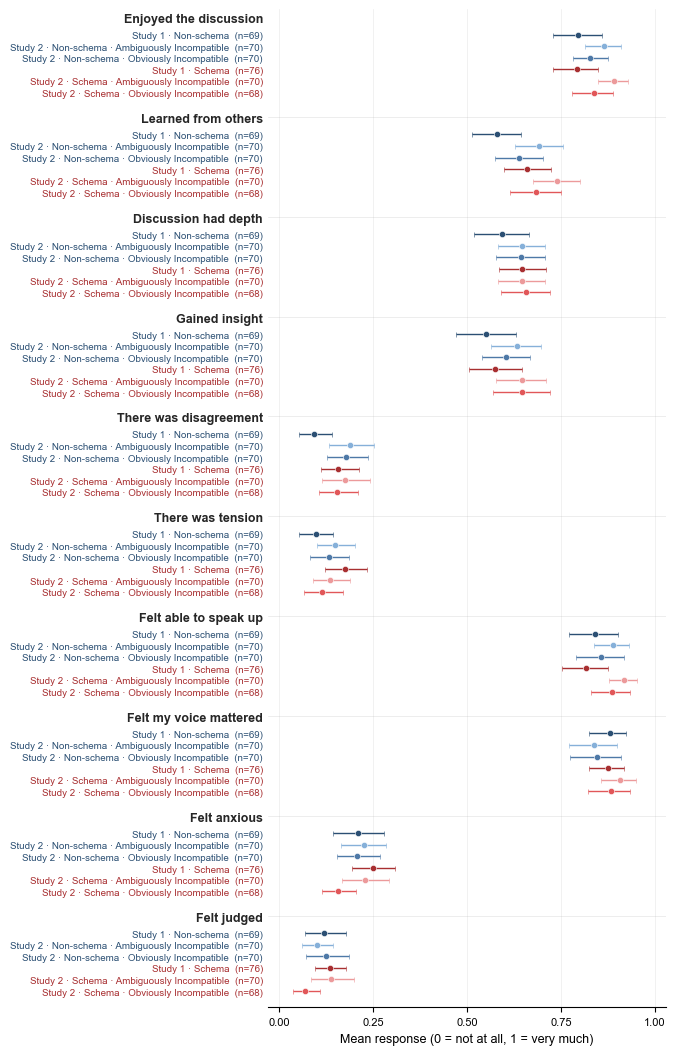

In [32]:
# [fig-discussion-survey]
# SI FIGURE (PNAS-formatted): post-game discussion-experience items across ALL SIX
# conditions from both studies on one shared x-axis. Each item is a bold header with
# its conditions as fully-labelled sub-rows (mean + 95% bootstrap CI). Colour family
# (blue = Non-schema, red = Schema) is a redundant cue alongside the row labels; shade
# tracks study/change type. Raw dots are omitted -- with six labelled lanes per item
# the means + CIs read far more cleanly. Saved to figures/ as PDF + 300-dpi PNG.
import os, glob, json as _json

pnas_style = {'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 7, 'legend.fontsize': 7.5,
    'axes.linewidth': 0.8, 'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'lines.linewidth': 1.5, 'lines.markersize': 5, 'patch.linewidth': 0.6}

# Load Study 1's discussion survey (schema/nonschema arms; survey completers, i.e.
# participants who reached the end -- effectively the analyzed sample for this item).
_s1rows = []
for _fn in sorted(glob.glob("../data/study_1_schema_nonschema/batch_*.scienceData.jsonl")):
    for _line in open(_fn):
        _r = _json.loads(_line)
        if _r.get("sampleId") == "missing":
            continue
        _t = _r.get("treatment")
        _tn = _t.get("name") if isinstance(_t, dict) else None
        if _tn not in ("schema", "nonschema"):
            continue
        _resp = {}
        for _v in (_r.get("surveys") or {}).values():
            if isinstance(_v, dict) and _v.get("surveyName") == "discussionGeneral":
                _resp = _v.get("responses") or {}
        if not _resp:
            continue
        _row = {"treatmentGroup": _tn}
        for _it in DISCUSSION_ITEMS:
            try:
                _row[f"disc_{_it}"] = float(_resp.get(_it))
            except (TypeError, ValueError):
                _row[f"disc_{_it}"] = np.nan
        _s1rows.append(_row)
s1_disc = pd.DataFrame(_s1rows)
print(f"Study 1 discussion-survey responders (schema/nonschema): {len(s1_disc)}")

# Six condition series (top -> bottom within each item). Blues = Non-schema, reds =
# Schema; light = Ambiguously Incompatible, mid = Obviously Incompatible, dark = Study 1.
series = [
    dict(label="Study 1 · Non-schema",              src="s1", tg="nonschema", ct=None,           color="#2B4F73"),
    dict(label="Study 2 · Non-schema · Ambiguously Incompatible", src="s2", tg="nonschema", ct="ambiguous",    color="#86B0D9"),
    dict(label="Study 2 · Non-schema · Obviously Incompatible",   src="s2", tg="nonschema", ct="incompatible", color="#4E79A7"),
    dict(label="Study 1 · Schema",                  src="s1", tg="schema",    ct=None,           color="#A82F31"),
    dict(label="Study 2 · Schema · Ambiguously Incompatible",     src="s2", tg="schema",    ct="ambiguous",    color="#EC9A9B"),
    dict(label="Study 2 · Schema · Obviously Incompatible",       src="s2", tg="schema",    ct="incompatible", color="#E15759"),
]

def _vals(s, it):
    if s["src"] == "s1":
        sub = s1_disc[s1_disc["treatmentGroup"] == s["tg"]]
    else:
        sub = all_data[(all_data["treatmentGroup"] == s["tg"]) &
                       (all_data["changeType"] == s["ct"])]
    return sub[f"disc_{it}"].dropna().values

for s in series:                                   # per-series n for the row labels
    s["n"] = len(_vals(s, list(DISCUSSION_ITEMS)[0]))

items = list(DISCUSSION_ITEMS)
N_S = len(series)
GROUP_GAP = 2.6
STEP = N_S + GROUP_GAP

with plt.rc_context(pnas_style):
    fig, ax = plt.subplots(figsize=(6.8, 10.6))
    yticks, yticklabels = [], []
    for ii, it in enumerate(items):
        base = ii * STEP
        # right-align the group header with the right edge of the y-tick labels
        ax.annotate(DISCUSSION_ITEMS[it], xy=(0, -base + 1.35),
                    xycoords=ax.get_yaxis_transform(),
                    xytext=(-plt.rcParams["ytick.major.pad"], 0), textcoords="offset points",
                    ha="right", va="center", fontweight="bold", fontsize=9,
                    color="0.15", annotation_clip=False)
        if ii > 0:                                  # faint separator above each group
            ax.axhline(-base + (GROUP_GAP / 2 + 0.2), color="0.9",
                       linewidth=0.5, zorder=0)
        for si, s in enumerate(series):
            yy = -(base + si)
            m, lo, hi = _boot_ci(_vals(s, it))
            ax.errorbar([m], [yy], xerr=[[m - lo], [hi - m]], fmt="o",
                        color=s["color"], markersize=4.5, markeredgecolor="white",
                        markeredgewidth=0.4, elinewidth=1, capsize=1.8, capthick=1,
                        zorder=4)
            yticks.append(yy)
            yticklabels.append(f"{s['label']}  (n={s['n']})")
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    for tick, s in zip(ax.get_yticklabels(), series * len(items)):
        tick.set_color("#2B4F73" if s["tg"] == "nonschema" else "#A82F31")  # readable family colour
    ax.set_ylim(-((len(items) - 1) * STEP + (N_S - 1)) - 1.4, 2.2)
    ax.set_xlim(-0.03, 1.03)
    ax.set_xticks(np.arange(0, 1.01, 0.25))
    ax.set_xlabel("Mean response (0 = not at all, 1 = very much)")
    ax.grid(axis="x", alpha=0.25, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig("figures/figureS3.pdf", bbox_inches="tight")
    plt.savefig("figures/figureS3.png", dpi=300, bbox_inches="tight")
    plt.show()


In [33]:
# [open-responses]
# Qualitative: the three open-text reflection prompts, grouped by design cell,
# restricted to the analyzed sample. Printed verbatim (participants' own words) so
# the schema vs nonschema strategies and error modes can be read directly.
OPEN_PROMPTS = {
    "prompt_strategy":         "STRATEGY  -- naming strategy and whether/why it changed across rounds",
    "prompt_mistake":          "MISTAKES  -- mistakes made and why",
    "prompt_working_together": "TEAMWORK  -- how the pair worked together",
}
open_by_sample = {
    row["sampleId"]: {k: (row.get("prompts") or {}).get(k, {})
                      for k in OPEN_PROMPTS}
    for row in raw if row["sampleId"] != "missing"
}
for k in OPEN_PROMPTS:
    all_data[k] = all_data["sampleId"].map(
        lambda s, k=k: str((open_by_sample.get(s, {}).get(k) or {}).get("value", "")).strip())

def print_open(prompt_key):
    print("=" * 95)
    print(OPEN_PROMPTS[prompt_key])
    print("=" * 95)
    for (tg, ct), g in all_data.groupby(["treatmentGroup", "changeType"]):
        rows = [(r["gameId"], r["position"], r[prompt_key])
                for _, r in g.iterrows() if r[prompt_key]]
        print(f"\n--- {tg} / {ct}   ({len(rows)} non-blank responses) ---")
        for gid, pos, text in rows:
            print(f"  [{gid} {pos}] {text}")

for k in OPEN_PROMPTS:
    print_open(k)
    print()

STRATEGY  -- naming strategy and whether/why it changed across rounds

--- nonschema / ambiguous   (70 non-blank responses) ---
  [2NM4F8 1] we first looked at the shapes of the blocks. We named the pictures by their outlooks, for example animals. This method worked very well. But eventually there were more and more pictures and different colours. So we named the pictures also by the colours. We did it very good.
  [2NM4F8 0] We initially started off trying to identify what the item was (an animal or other object), but then we started to use colours in round 2.  That work really well, so we continued with that strategy as we went along through the other rounds. If there was the same colour twice, we came up with a simple word (eg. tall) I know I made one mistake as I couldn't remember if we agreed on yellow or orange in the last round, but I believe that was our only error.
  [MFB0SJ 0] we tried to assign the images with characters we remember or the color they are, we kept it simple a